# LOGISTIC REGRESSION MODEL FOR DIABETES DIAGNOSE

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, QuantileTransformer, FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import joblib
import re


pd.set_option('display.max_columns', 23)
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2023.csv')
df.loc[df['KidneyDisease'] == 2, 'KidneyDisease'] = 0
df.loc[df['Asthma'] == 2, 'Asthma'] = 0
df.loc[df['COPD'] == 2, 'COPD'] = 0

## Data Preprocessing

### Handling Missing Data
drop the rows which includes unknown features which are detected during EDA

Since rows with unknown feature are a small proportion of our dataset (we know it thanks to EDA), best way to to handle unknown data is dropping the rows with unknown feature 

In [91]:
df = df[df['KidneyDisease'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['Asthma'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['COPD'].isin([0.0,1.0])].reset_index(drop=True)

### Feature Encoding
All ordinal variables are already ordinal encoded in dataset

All nominal features are already encoded (Since all nominal features are based on yes/no answers they are binary labeled as 0/1)  in dataset

Then there is no need to any further feature encoding

### Scaling the Data
Since there are too many possible combinations for column transformation I will try the most logical combinations

The reasoning behind the tranformation/scaling selection is that to see whether the best scaling/tranformation method for a feature which is not distributed normally or not balanced.

From EDA:
- The distribution of the BMI feature appears to be approximately normal
- The distributions of the ordinal features appear to be unbalanced 
- I do not apply any scaling to my nominal variables(since they are binary labeled as 0/1)

I create some scaling options for comparing the effects of scaling decisions on the model's success

In [3]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

scaling_options = [
    #----------------------------------------------------------------------bmi_scaler = StandardScaler()----------------------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    #------------------------------------------------ bmi_scaler = RobustScaler() ---------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    #---------------------------------------------------- bmi_scaler = MinMaxScaler()------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    #------------------------------------------------------ bmi_scaler = QuantileTransformer(output_distribution='uniform')------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )
]

## Splitting Data into Train and Test Data

Split the data and guarantee the both train and test sets are balanced

Cross validation will be applied during hyperparameter tunning via GridSearchCV 

In [92]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

In [158]:
counts = np.bincount(y)
counts / counts.sum()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12216\89429679.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y)


array([0.46863847, 0.53136153])

In [154]:
counts = np.bincount(y_train)
counts / counts.sum()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12216\2684850836.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


array([0.47065126, 0.52934874])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12216\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x1ab42be4d60>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

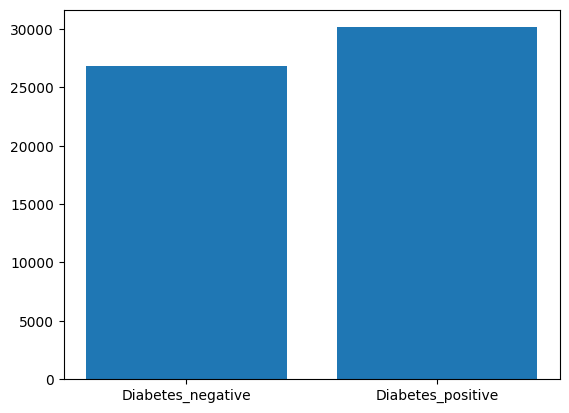

In [152]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12216\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x1ab42ab6260>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

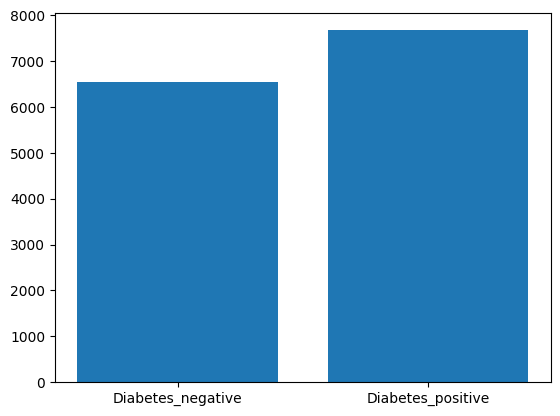

In [155]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

In [157]:
counts = np.bincount(y_test)
counts / counts.sum()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12216\1517005434.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


array([0.46058733, 0.53941267])

## Pipeline

- In scaling part the data will be scaled
- In model part the model will be trained

In [7]:
pipe = Pipeline([
    ("scaling",StandardScaler()),
    ("model", LogisticRegression())
])

## Hyperparameter Tuning

- Try every possible combinations with GridSearch and then register all hyperparameter groups' performances metrics for to compare
- For hyperparamatertuning use Cross Validation with 5 fold

In [ ]:
param_grids = [
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["lbfgs"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["lbfgs"]
    },

    #-------------------------lbfgs-----------------------------------------

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2","l1"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["liblinear"]
    },
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2","l1"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["liblinear"]
    },
    #-------------------------liblinear----------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["newton-cholesky"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["newton-cholesky"]
    },
    #-----------------------------newton-cholesky--------------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["newton-cg"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["newton-cg"]
    },
     #--------------------------------- newton-cg ----------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["sag"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["sag"]
    },
    #-----------------------------sag--------------------------------------------------
]

In [10]:
grid = GridSearchCV(pipe, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"[{'model__C': [0.1, 0.2, ...], 'model__max_iter': [30, 50, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], ...}, {'model__max_iter': [30, 50, ...], 'model__penalty': [None], 'model__solver': ['lbfgs'], 'scaling': [ColumnTransfo...lk', 'Sex'])]), ColumnTransfo...lk', 'Sex'])]), ...]}, ...]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [14]:
grid.best_params_

{'model__C': 0.1,
 'model__max_iter': 400,
 'model__penalty': 'l2',
 'model__solver': 'liblinear',
 'scaling': ColumnTransformer(remainder='passthrough',
                   transformers=[('ordinal_scaler', RobustScaler(),
                                  ['GenHlth', 'MentHlth', 'PhysHlth', 'AgeGroup',
                                   'Education', 'Income']),
                                 ('bmi_scaler', QuantileTransformer(), ['BMI']),
                                 ('pass_nominal', 'passthrough',
                                  ['KidneyDisease', 'HighBP', 'HighChol',
                                   'CholCheck', 'Asthma', 'COPD', 'Smoker',
                                   'Stroke', 'HeartDiseaseorAttack',
                                   'HvyAlcoholConsump', 'AnyHealthcare',
                                   'NoDocbcCost', 'DiffWalk', 'Sex'])])}

In [ ]:
best_model = grid.best_estimator_

## Save the Performance Metrics of Models and the Best Model

In [ ]:
#grid_results_df = pd.DataFrame(grid.cv_results_)
#grid_results_df.to_csv("grid_results.csv", index=False)

In [95]:
grid_results_df = pd.read_csv("grid_results.csv")
grid_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__max_iter,param_model__penalty,param_model__solver,param_scaling,params,split0_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,0.288027,0.013748,0.045579,0.002308,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.737267,...,0.762743,0.003571,6810,0.809790,0.816496,0.817666,0.818569,0.813573,0.815219,0.003194,1631
1,0.274706,0.017603,0.043415,0.004056,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.738058,...,0.763154,0.003416,4380,0.809749,0.816383,0.817700,0.818439,0.813507,0.815156,0.003185,3417
2,0.325193,0.023258,0.062566,0.006905,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.737443,...,0.760665,0.003180,7516,0.808084,0.814736,0.814894,0.816789,0.811193,0.813139,0.003108,7264
3,0.319201,0.018238,0.044917,0.004920,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.737706,...,0.762997,0.003383,6344,0.809797,0.816305,0.817736,0.818404,0.813519,0.815152,0.003160,4339
4,0.247351,0.025853,0.045918,0.002603,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.737443,...,0.762818,0.003593,6744,0.809790,0.816494,0.817656,0.818558,0.813549,0.815209,0.003193,1702


In [ ]:
#joblib.dump(best_model, 'best_logistic_model.pkl')

['best_logistic_model.pkl']

In [93]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model.pkl')

# Model Evaluation

## Best model's success metrics

### Checking Train Success

In [5]:
y_pred = best_model1.predict(X_train)

In [6]:
accuracy_train = accuracy_score(y_train, y_pred)
accuracy_train

0.7444147815090628

In [7]:
precision_train = precision_score(y_train, y_pred)
precision_train

0.7433111673066717

In [8]:
recall_train = recall_score(y_train, y_pred)
recall_train

0.7899731245230432

In [9]:
f1_score_train = f1_score(y_train, y_pred)
f1_score_train

0.7659321216020589

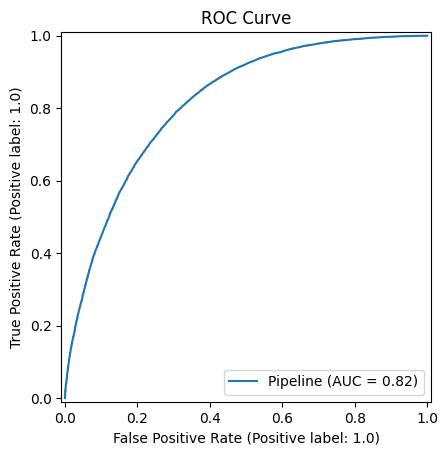

In [10]:
RocCurveDisplay.from_estimator(best_model1, X_train, y_train)
plt.title("ROC Curve")
plt.show()


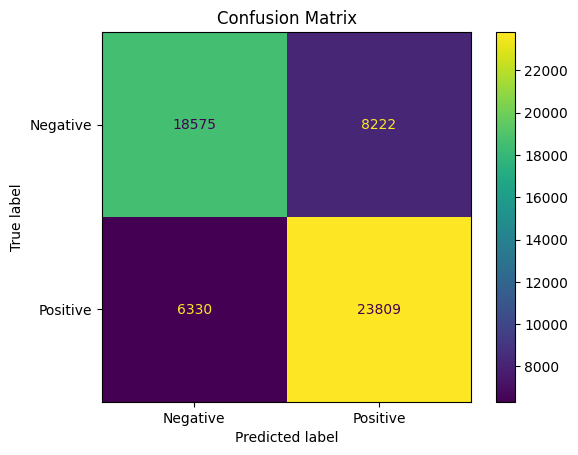

In [11]:
disp = ConfusionMatrixDisplay.from_predictions(y_train, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

### Trying best model with current test split (%80 train/ %20 test)

In [10]:
y_pred = best_model1.predict(X_test)


In [11]:
best_model1.named_steps["model"].n_iter_

array([5], dtype=int32)

In [12]:
weights = best_model1.named_steps["model"].coef_[0]

#### Checking Weights of Features

In [13]:
coef_df = pd.DataFrame({
    "columns": [  'KidneyDisease', 'HighBP', 'HighChol', 'CholCheck',
                'Asthma', 'COPD', 'BMI', 'Smoker', 'Stroke', 
                'HeartDiseaseorAttack','PhysActivity', 'HvyAlcoholConsump', 
                'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 
                'PhysHlth', 'DiffWalk', 'Sex', 'AgeGroup','Education', 'Income'],      
    "weight": weights
})

coef_df.head(22)

,columns,weight
0,KidneyDisease,1.020892
1,HighBP,-0.019824
2,HighChol,-0.037839
3,CholCheck,0.589026
4,Asthma,-0.172076
5,COPD,-0.194945
6,BMI,1.622944
7,Smoker,0.651060
8,Stroke,0.661890
9,HeartDiseaseorAttack,0.536738


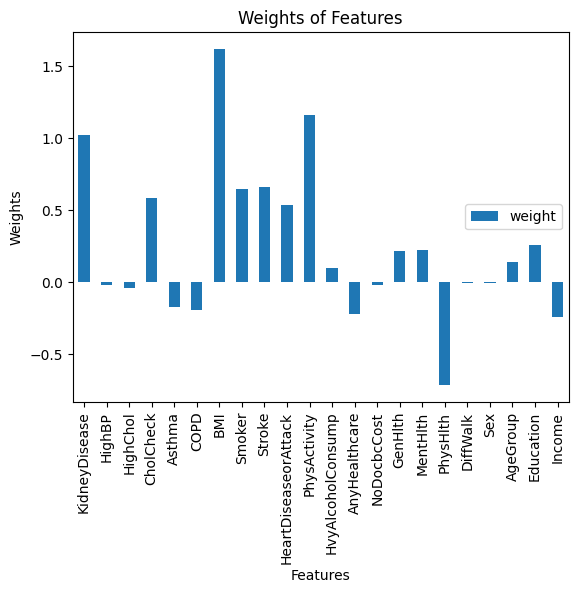

In [14]:
coef_df.plot(kind='bar', x='columns')

plt.xlabel("Features")
plt.ylabel("Weights")
plt.title("Weights of Features")
plt.legend(loc="center right")
plt.show()

In [15]:
coef_df_abs = coef_df.copy()
coef_df_abs["weight"] = coef_df_abs["weight"].abs()
coef_df_abs.head(22)

,columns,weight
0,KidneyDisease,1.020892
1,HighBP,0.019824
2,HighChol,0.037839
3,CholCheck,0.589026
4,Asthma,0.172076
5,COPD,0.194945
6,BMI,1.622944
7,Smoker,0.651060
8,Stroke,0.661890
9,HeartDiseaseorAttack,0.536738


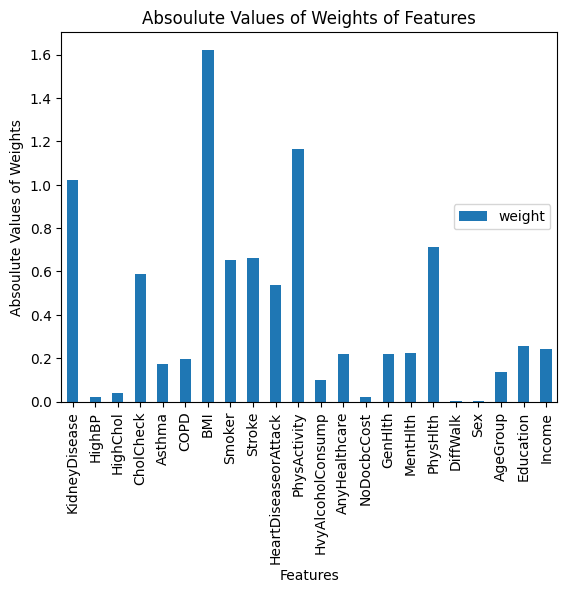

In [16]:
coef_df_abs.plot(kind='bar', x='columns')

plt.xlabel("Features")
plt.ylabel("Absoulute Values of Weights")
plt.title("Absoulute Values of Weights of Features")
plt.legend(loc="center right")
plt.show()

#### Succes Metrics

In [17]:
accuracy_1 = accuracy_score(y_test, y_pred)
accuracy_1

0.7479977518617394

In [18]:
precision_1 = precision_score(y_test, y_pred)
precision_1

0.753815609877156

In [19]:
recall_1 = recall_score(y_test, y_pred)
recall_1

0.7912216723104976

In [20]:
f1_score_1 = f1_score(y_test, y_pred)
f1_score_1

0.7720658321153968

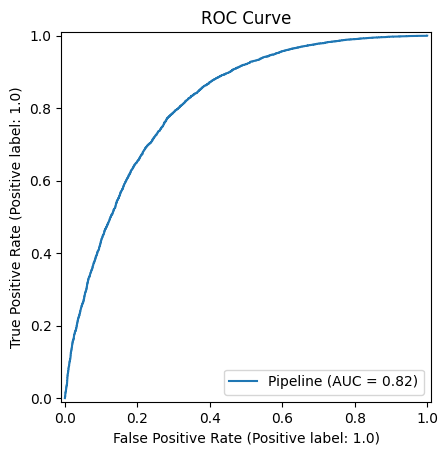

In [21]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


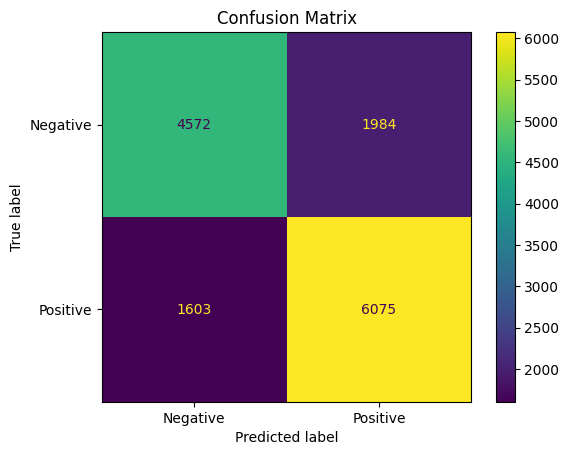

In [22]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

## Checking Overfitting - Underfitting

### Train Score vs Test Score

In [84]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_train, precision_train, recall_train, f1_score_train]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model(test success)', 'best_model(train_succes)']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
best_model(test success),0.747998,0.753816,0.791222,0.772066
best_model(train_succes),0.744415,0.743311,0.789973,0.765932


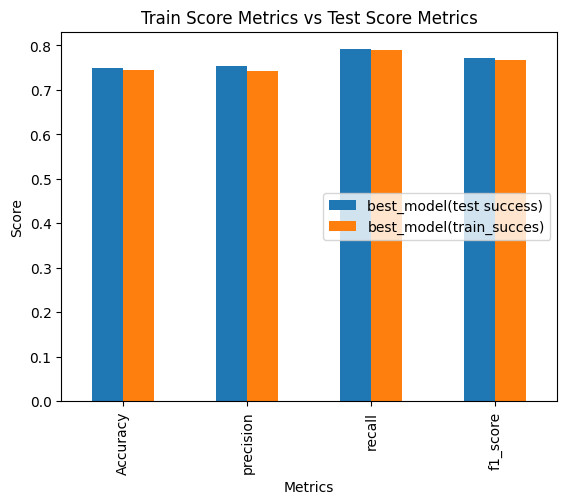

In [85]:
best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Train Score Metrics vs Test Score Metrics")
plt.legend(loc="center right")
plt.show()

### Validation loss vs Train loss

In [ ]:
accuracy_val = cross_val_score(best_model1, X_train, y_train, cv=5, scoring="accuracy")
precision_val = cross_val_score(best_model1, X_train, y_train, cv=5, scoring="precision")
recall_val = cross_val_score(best_model1, X_train, y_train, cv=5, scoring="recall")
f1_score_val = cross_val_score(best_model1, X_train, y_train, cv=5, scoring="f1")

In [16]:
print("Std of accuracy: ", accuracy_val.std())
print("Std of accuracy: ", precision_val.std())
print("Std of accuracy: ", recall_val.std())
print("Std of accuracy: ", f1_score_val.std())

Std of accuracy:  0.003077176303544664
Std of accuracy:  0.00265262520899949
Std of accuracy:  0.0063773192343775185
Std of accuracy:  0.0034883049301706894


In [17]:
accuracy_val_mean = accuracy_val.mean()
precision_val_mean = precision_val.mean()
recall_val_mean = recall_val.mean()
f1_score_val_mean = f1_score_val.mean()

In [18]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_val_mean, precision_val_mean, recall_val_mean, f1_score_val_mean], [accuracy_train, precision_train, recall_train, f1_score_train]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['validation success', 'train_succes']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
validation success,0.743835,0.742742,0.789541,0.765322
train_succes,0.744415,0.743311,0.789973,0.765932


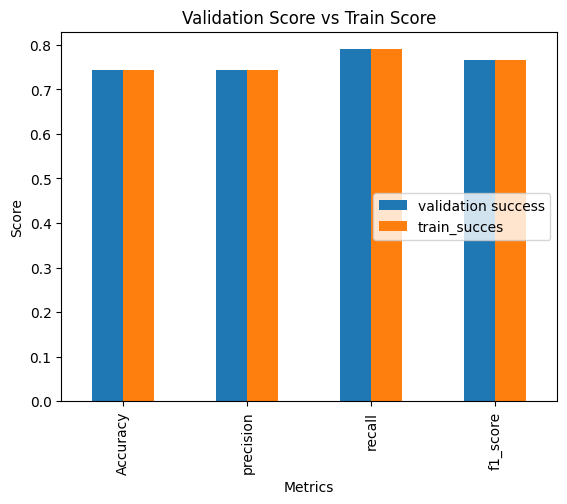

In [19]:
best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Validation Score vs Train Score")
plt.legend(loc="center right")
plt.show()

### Learning Curve

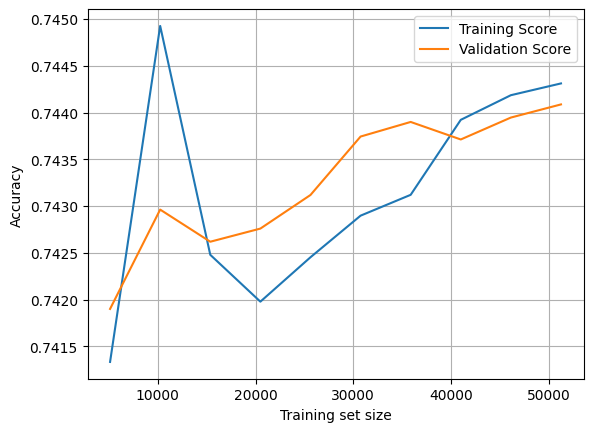

In [68]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

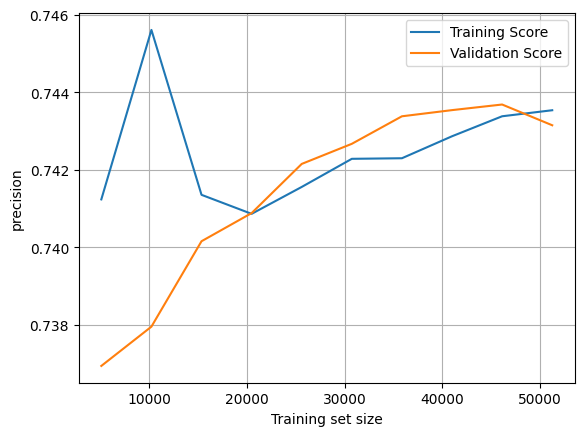

In [61]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="precision",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("precision")
plt.legend()
plt.grid()
plt.show()

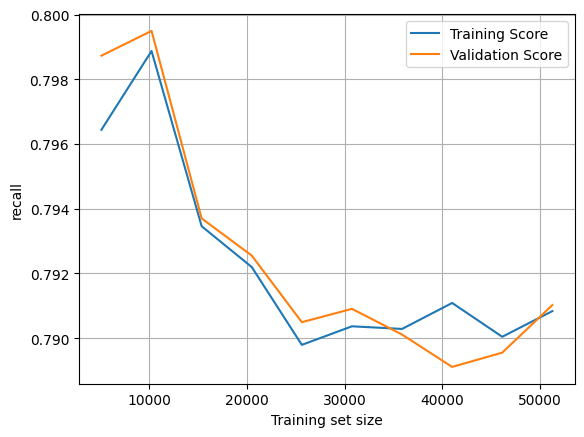

In [63]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="recall",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("recall")
plt.legend()
plt.grid()
plt.show()

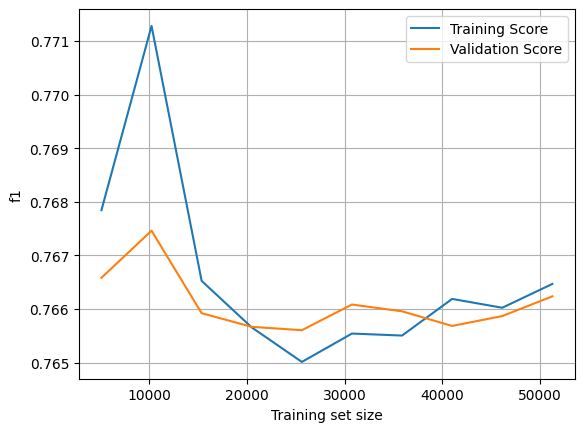

In [64]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="f1",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("f1")
plt.legend()
plt.grid()
plt.show()

## Trying best model with a larger train split (%90 train/ %10 test)

#### Splitting data (%90 train /%10 test)

In [86]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state= 28)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3728\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x1964a771930>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

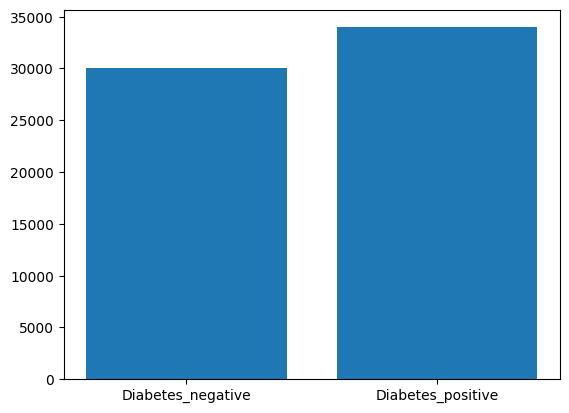

In [13]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3728\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x1962dc61f60>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

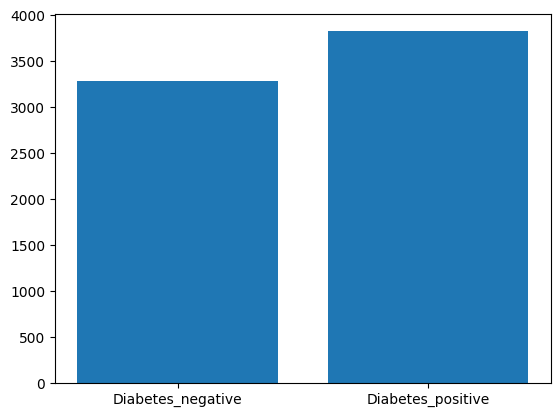

In [14]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

#### Evaluating Model

In [87]:
best_model1.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
y_pred = best_model1.predict(X_test)


In [28]:
best_model1.named_steps["model"].n_iter_

array([5], dtype=int32)

In [89]:
accuracy_2 = accuracy_score(y_test, y_pred)
accuracy_2

0.7497541098777575

In [90]:
precision_2 = precision_score(y_test, y_pred)
precision_2

0.7544121302510565

In [91]:
recall_2 = recall_score(y_test, y_pred)
recall_2

0.7928422152560084

In [92]:
f1_score_2 = f1_score(y_test, y_pred)
f1_score_2

0.773149917207999

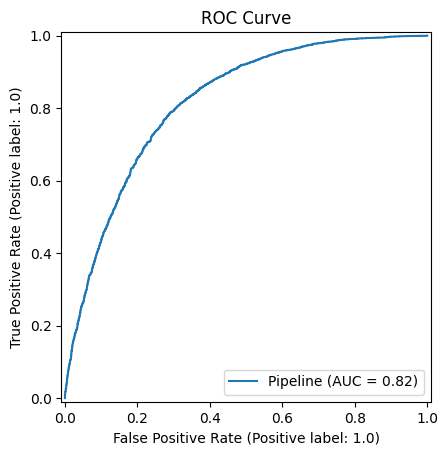

In [93]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


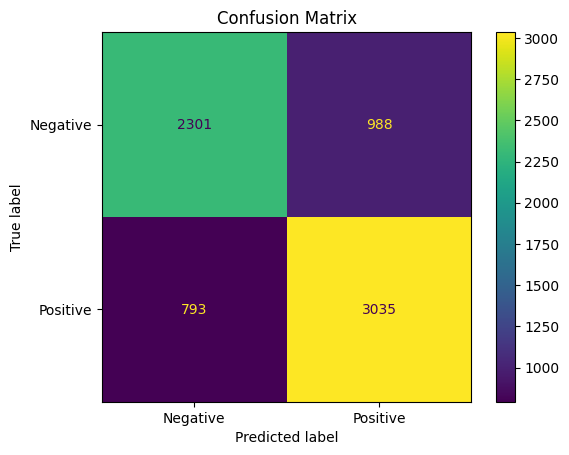

In [94]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [95]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_2, precision_2, recall_2, f1_score_2]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model(%20 test split)', 'best_model(%10 test split)']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
best_model(%20 test split),0.747998,0.753816,0.791222,0.772066
best_model(%10 test split),0.749754,0.754412,0.792842,0.773150


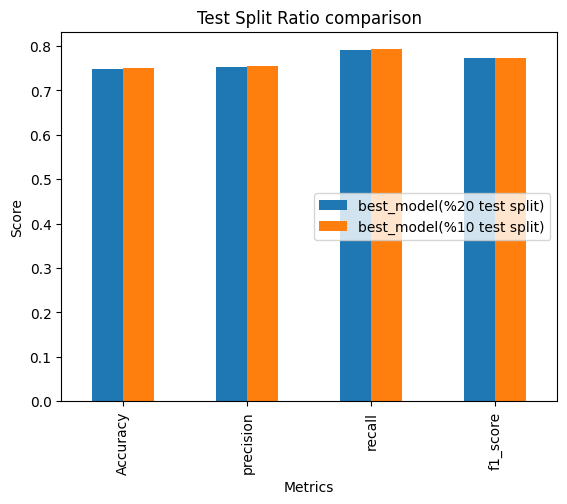

In [96]:

best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Test Split Ratio comparison")
plt.legend(loc="center right")
plt.show()

In [287]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model.pkl')

## Comparing Metrics of Different Hyperparameter Combinations
In this section, I will analyze the how the changes in hyperparameters affects on models' success 

- Before I use mean of similar models' metrics to observe how the change in a parameter affects on model's success, I checked the standard deviation of that metric and verify that standard deviation of that metric is small.        

In [110]:
grid_results_df.shape

(8512, 50)

In [111]:
grid_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__C', 'param_model__max_iter', 'param_model__penalty',
       'param_model__solver', 'param_scaling', 'params',
       'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy',
       'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy',
       'std_test_accuracy', 'rank_test_accuracy', 'split0_test_precision',
       'split1_test_precision', 'split2_test_precision',
       'split3_test_precision', 'split4_test_precision', 'mean_test_precision',
       'std_test_precision', 'rank_test_precision', 'split0_test_recall',
       'split1_test_recall', 'split2_test_recall', 'split3_test_recall',
       'split4_test_recall', 'mean_test_recall', 'std_test_recall',
       'rank_test_recall', 'split0_test_f1', 'split1_test_f1',
       'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1',
       'std_test_f1', 'rank_test_f1', 'split0_test_roc_auc',
       '

In [112]:
param_cols = ['param_model__C', 'param_model__max_iter', 'param_model__penalty','param_model__solver', 'param_scaling', 'params']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [113]:
grid_results_df[std_cols].describe()
# standard deviation is small so folds are well partitioned during cross validation

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000
mean,0.186140,0.009909,0.002981,0.002178,0.006422,0.003442,0.003219
std,0.501251,0.169316,0.000207,0.000231,0.000230,0.000188,0.000096
min,0.000930,0.000275,0.002200,0.001067,0.005212,0.002721,0.003016
25%,0.018198,0.004430,0.002899,0.002142,0.006262,0.003359,0.003182
50%,0.039927,0.006381,0.002975,0.002206,0.006374,0.003414,0.003194
75%,0.095210,0.008966,0.003071,0.002301,0.006584,0.003483,0.003210
max,19.107063,15.601071,0.003654,0.002787,0.007289,0.004128,0.003434


### Model's Solver's Effects on Model's Metrics
- It is observed that change in model's solver has no significant effect on models success 

In [114]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(5)


,param_model__solver,test_accuracy_std,test_f1_std,roc_auc_std
0,lbfgs,0.001083,0.001372,0.000991
1,liblinear,0.001079,0.001367,0.000989
2,newton-cg,0.001089,0.001378,0.000994
3,newton-cholesky,0.001088,0.001375,0.000992
4,sag,0.001092,0.001377,0.000993


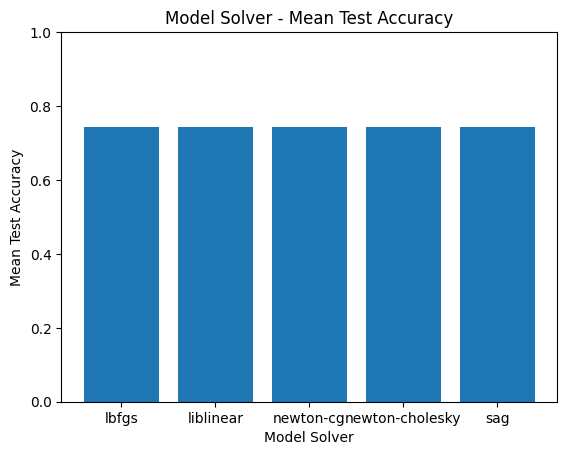

In [115]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_accuracy"].mean().reset_index()

plt.bar(results["param_model__solver"], results["mean_test_accuracy"])
plt.xlabel("Model Solver")
plt.ylabel("Mean Test Accuracy")
plt.title("Model Solver - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

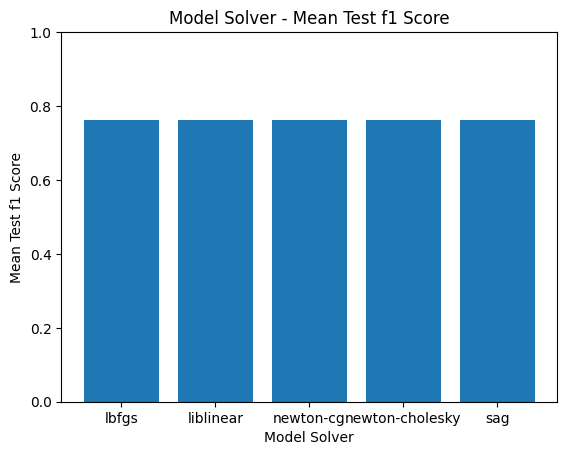

In [116]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_f1"].mean().reset_index()



plt.bar(results["param_model__solver"], results["mean_test_f1"])
plt.xlabel("Model Solver")
plt.ylabel("Mean Test f1 Score")
plt.title("Model Solver - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

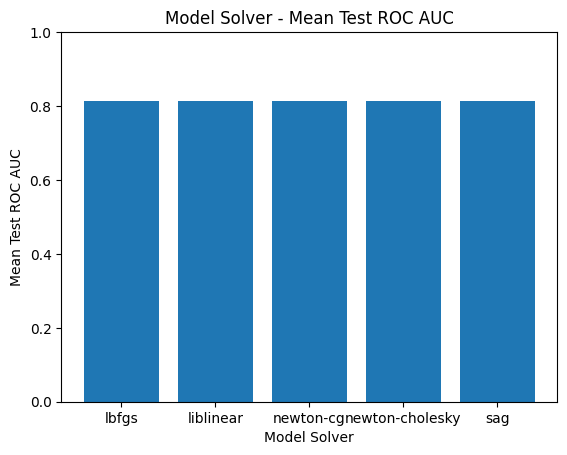

In [117]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_roc_auc"].mean().reset_index()



plt.bar(results["param_model__solver"], results["mean_test_roc_auc"])
plt.xlabel("Model Solver")
plt.ylabel("Mean Test ROC AUC")
plt.title("Model Solver - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

### Model's Penalty's Effects on Model's Metrics 

In [118]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(2)


,param_model__penalty,test_accuracy_std,test_f1_std,roc_auc_std
0,l1,0.001083,0.001371,0.000984
1,l2,0.001082,0.001370,0.000993


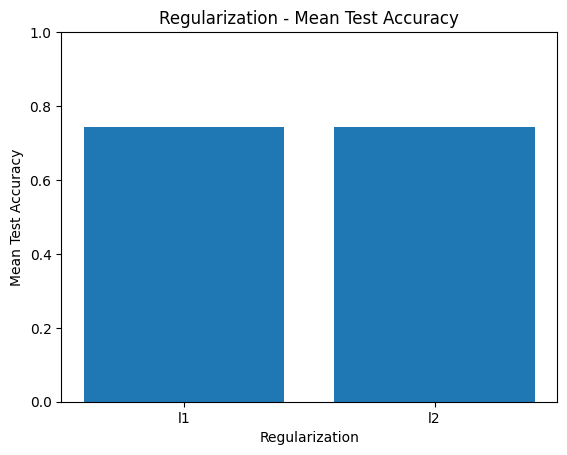

In [125]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_accuracy"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_accuracy"])
plt.xlabel("Regularization")
plt.ylabel("Mean Test Accuracy")
plt.title("Regularization - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

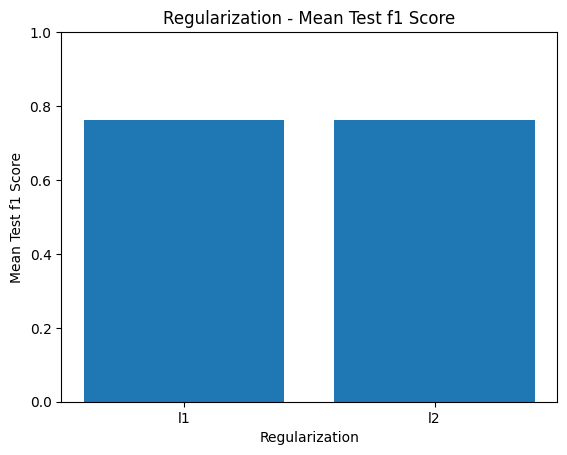

In [126]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_f1"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_f1"])
plt.xlabel("Regularization")
plt.ylabel("Mean Test f1 Score")
plt.title("Regularization - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

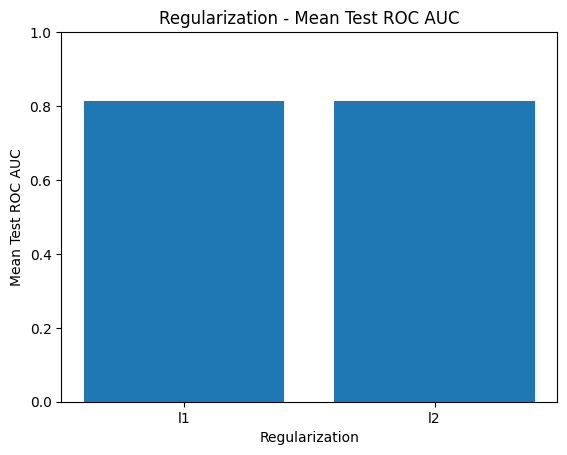

In [127]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_roc_auc"])
plt.xlabel("Regularization")
plt.ylabel("Mean Test ROC AUC")
plt.title("Regularization - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

### Max Number of Iteration's Effects on Model's Metrics

In [128]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(7)


,param_model__max_iter,test_accuracy_std,test_f1_std,roc_auc_std
0,30,0.001083,0.001372,0.000990
1,50,0.001088,0.001375,0.000990
2,100,0.001084,0.001371,0.000991
3,150,0.001085,0.001372,0.000992
4,200,0.001086,0.001373,0.000990
5,300,0.001084,0.001372,0.000991
6,400,0.001079,0.001367,0.000991


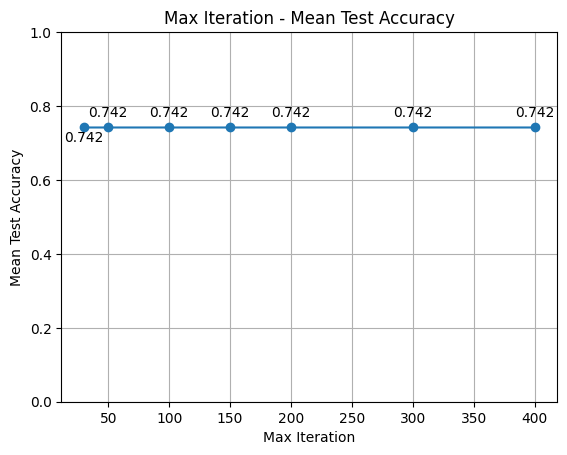

In [129]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("Max Iteration")
plt.ylabel("Mean Test Accuracy")
plt.title("Max Iteration - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

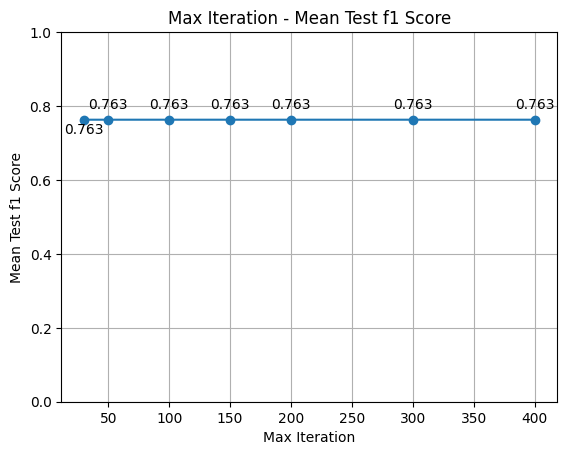

In [130]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_f1"], marker = "o")
plt.xlabel("Max Iteration")
plt.ylabel("Mean Test f1 Score")
plt.title("Max Iteration - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

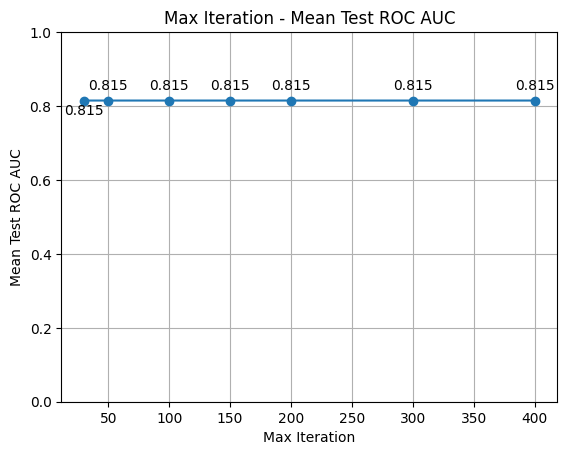

In [131]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("Max Iteration")
plt.ylabel("Mean Test ROC AUC")
plt.title("Max Iteration - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

### Value of C's Effects on Model's Metrics

In [132]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(8)


,param_model__C,test_accuracy_std,test_f1_std,roc_auc_std
0,0.10,0.001076,0.001359,0.001026
1,0.20,0.001068,0.001356,0.000992
2,0.35,0.001051,0.001343,0.000985
3,0.50,0.001059,0.001351,0.000984
4,1.00,0.001079,0.001367,0.000986
5,1.50,0.001099,0.001386,0.000985
6,2.00,0.001101,0.001389,0.000986
7,5.00,0.001108,0.001395,0.000986


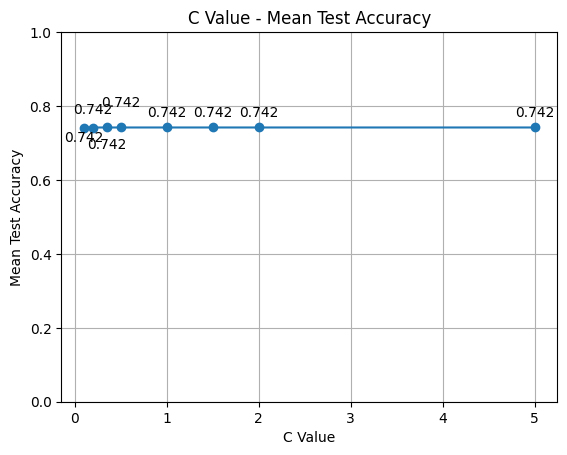

In [133]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("C Value")
plt.ylabel("Mean Test Accuracy")
plt.title("C Value - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

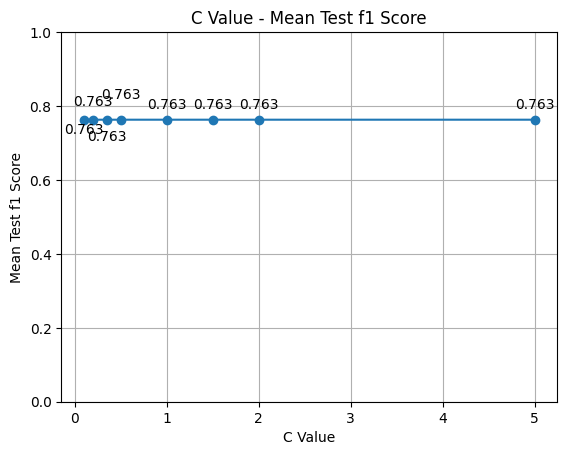

In [134]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_f1"], marker = "o")
plt.xlabel("C Value")
plt.ylabel("Mean Test f1 Score")
plt.title("C Value - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

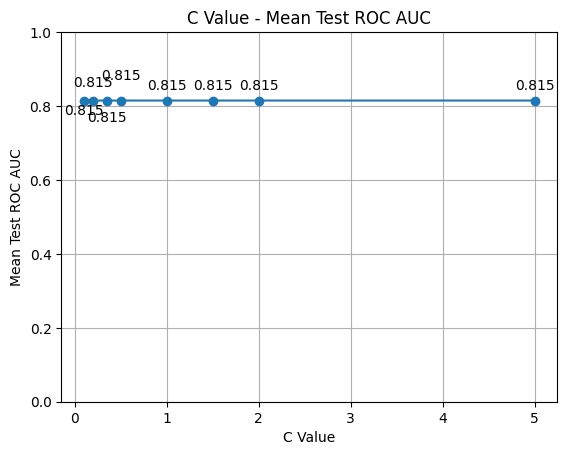

In [135]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("C Value")
plt.ylabel("Mean Test ROC AUC")
plt.title("C Value - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)


offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

### Scaling's Effects on Model's Metrics

In [10]:
#function for parsing the scalers in param_scaling column 
def parse_scaler(c):
    scaler_pattern = r"MinMaxScaler|StandardScaler|QuantileTransformer|RobustScaler"
    pattern = fr"ordinal_scaler', ({scaler_pattern}).*bmi_scaler', ({scaler_pattern})"
    x = re.search(pattern, c, flags=re.DOTALL)
    return [x.group(1), x.group(2)]


In [11]:
#add scalers type as seperate columns
results = grid_results_df[param_cols + mean_cols].copy()

results["ordinal_scaler"], results["bmi_scaler"] = zip(*results["param_scaling"].apply(parse_scaler))
results = results.drop(columns=param_cols)

#### Ordinal Scaler's Effects on Success Metrics

In [17]:
results_0 = results.groupby("ordinal_scaler", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results_0.head(4)


,ordinal_scaler,test_accuracy_std,test_f1_std,roc_auc_std
0,MinMaxScaler,0.000698,0.000849,0.000457
1,QuantileTransformer,0.001005,0.001156,0.000468
2,RobustScaler,0.000718,0.000857,0.000459
3,StandardScaler,0.000720,0.000860,0.000460


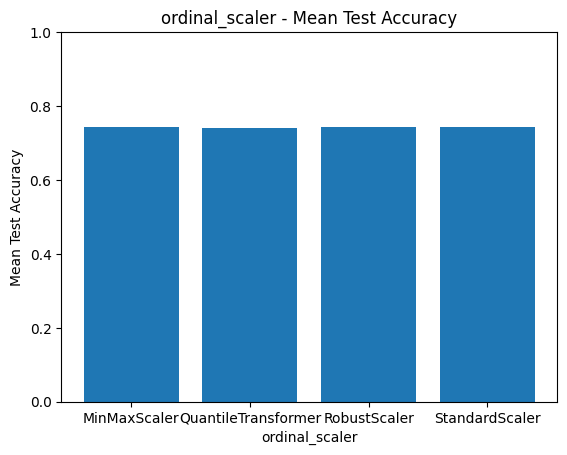

In [12]:
results_0 = results.groupby("ordinal_scaler")["mean_test_accuracy"].mean().reset_index()

plt.bar(results_0["ordinal_scaler"], results_0["mean_test_accuracy"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test Accuracy")
plt.title("ordinal_scaler - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

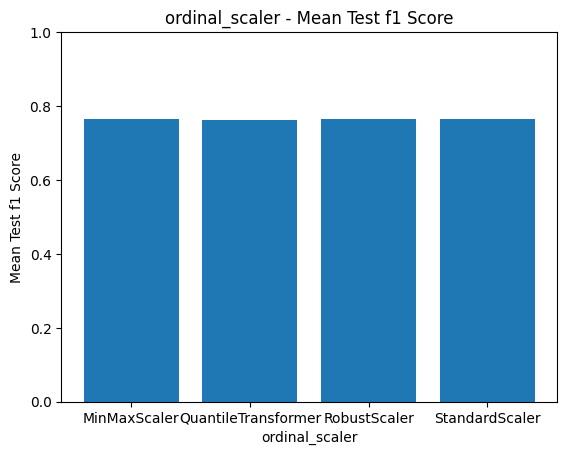

In [13]:
results_0 = results.groupby("ordinal_scaler")["mean_test_f1"].mean().reset_index()

plt.bar(results_0["ordinal_scaler"], results_0["mean_test_f1"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test f1 Score")
plt.title("ordinal_scaler - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

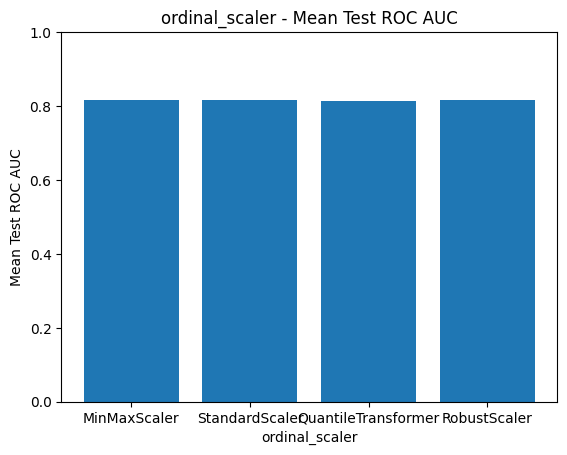

In [14]:
results_0 = results.groupby("ordinal_scaler")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["ordinal_scaler"], results["mean_test_roc_auc"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test ROC AUC")
plt.title("ordinal_scaler - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

#### Bmi Scaler's Effects on Success Metrics

In [20]:
results_0 = results.groupby("bmi_scaler", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results_0.head(4)

,bmi_scaler,test_accuracy_std,test_f1_std,roc_auc_std
0,MinMaxScaler,0.000782,0.001041,0.000891
1,QuantileTransformer,0.000532,0.000784,0.000868
2,RobustScaler,0.000843,0.001103,0.000881
3,StandardScaler,0.000838,0.001098,0.000882


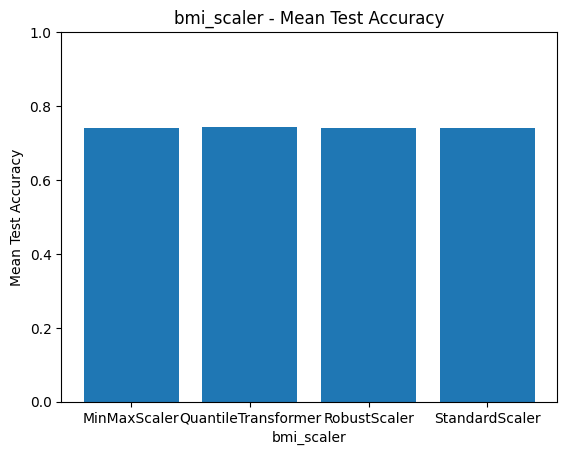

In [25]:
results_0 = results.groupby("bmi_scaler")["mean_test_accuracy"].mean().reset_index()

plt.bar(results_0["bmi_scaler"], results_0["mean_test_accuracy"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test Accuracy")
plt.title("bmi_scaler - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

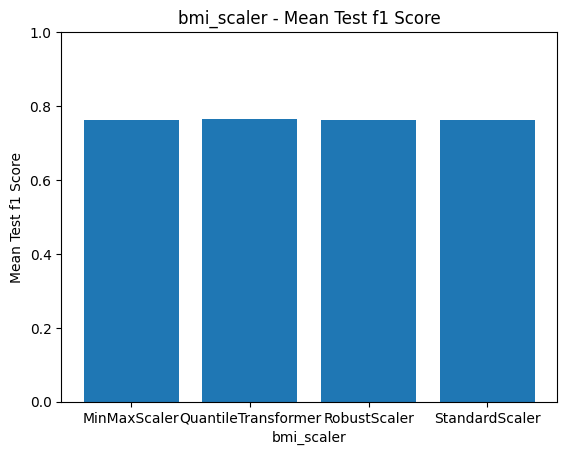

In [26]:
results_0 = results.groupby("bmi_scaler")["mean_test_f1"].mean().reset_index()

plt.bar(results_0["bmi_scaler"], results_0["mean_test_f1"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test f1 Score")
plt.title("bmi_scaler - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

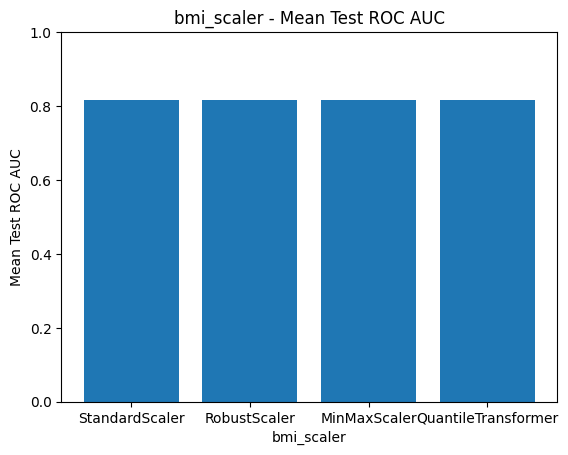

In [27]:
results_0 = results.groupby("bmi_scaler")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["bmi_scaler"], results["mean_test_roc_auc"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test ROC AUC")
plt.title("bmi_scaler - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

# Improving the Model

## Scaling Improvement

In [12]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

### QuantileTransformer's Parameters

In [14]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

Col_Transformer = ColumnTransformer (
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )

In [15]:
model_new = Pipeline([
    ("scaling",Col_Transformer),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [16]:
param_grids = [
    {
    "scaling__bmi_scaler__n_quantiles": [1000, 2000, 5000, 10000],
    "scaling__bmi_scaler__output_distribution": ['uniform', 'normal']
    }
]

In [17]:
grid = GridSearchCV(model_new, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'scaling__bmi_scaler__n_quantiles': [1000, 2000, ...], 'scaling__bmi_scaler__output_distribution': ['uniform', 'normal']}]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [18]:
bmi_scaler_result_df = pd.DataFrame(grid.cv_results_)

In [19]:
best_scaler_model = grid.best_estimator_

In [20]:
grid.best_params_

{'scaling__bmi_scaler__n_quantiles': 1000,
 'scaling__bmi_scaler__output_distribution': 'uniform'}

In [21]:
best_scaler_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = best_scaler_model.predict(X_test)

In [23]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new

0.7477167345791766

In [24]:
precision_new = precision_score(y_test, y_pred)
precision_new

0.7535674401290483

In [25]:
recall_new = recall_score(y_test, y_pred)
recall_new

0.7909611878093253

In [26]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new

0.7718116540636716

In [27]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['old_parameters', 'improved_parameters ']
)

In [28]:
model_performance_df.head(2)

,Accuracy,precision,recall,f1_score
old_parameters,0.747998,0.753816,0.791222,0.772066
improved_parameters,0.747717,0.753567,0.790961,0.771812


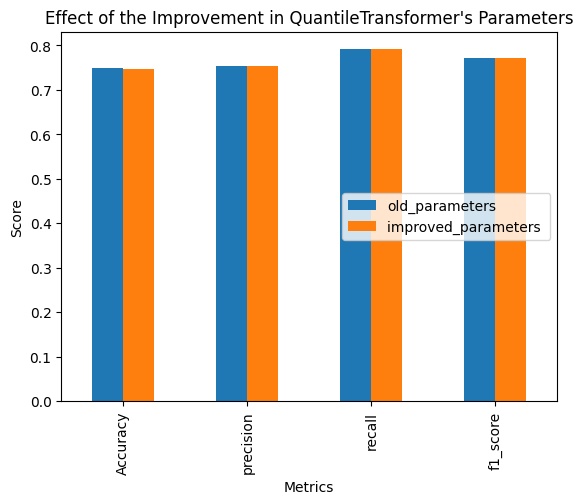

In [29]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Effect of the Improvement in QuantileTransformer's Parameters")
plt.legend(loc="center right")
plt.show()

In [35]:
param_cols =['param_scaling__bmi_scaler__n_quantiles', 'param_scaling__bmi_scaler__output_distribution']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [36]:
bmi_scaler_result_df.describe()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_scaling__bmi_scaler__n_quantiles,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000
mean,0.577064,0.054685,0.066534,0.007924,4500.000000,0.738563,0.743194,0.748002,0.745982,0.742755,0.743699,...,0.765164,0.003616,4.50000,0.810395,0.816952,0.819612,0.818925,0.814671,0.816111,0.003338,4.50000
std,0.047476,0.014727,0.010703,0.002676,3741.657387,0.000761,0.000474,0.000387,0.000717,0.000229,0.000090,...,0.000108,0.000244,2.44949,0.000016,0.000024,0.000277,0.000157,0.000077,0.000013,0.000035,2.44949
min,0.504514,0.039356,0.050405,0.003706,1000.000000,0.737706,0.742601,0.747519,0.745236,0.742426,0.743572,...,0.765003,0.003329,1.00000,0.810362,0.816912,0.819317,0.818769,0.814593,0.816086,0.003297,1.00000
25%,0.556421,0.046181,0.060879,0.006058,1750.000000,0.737838,0.742843,0.747695,0.745324,0.742645,0.743638,...,0.765106,0.003385,2.75000,0.810393,0.816943,0.819371,0.818772,0.814601,0.816109,0.003308,2.75000
50%,0.578610,0.051851,0.067842,0.009193,3500.000000,0.738628,0.743084,0.747914,0.745894,0.742733,0.743695,...,0.765165,0.003616,4.50000,0.810397,0.816950,0.819629,0.818930,0.814664,0.816116,0.003340,4.50000
75%,0.596974,0.057883,0.072957,0.009526,6250.000000,0.739155,0.743677,0.748331,0.746663,0.742887,0.743747,...,0.765236,0.003855,6.25000,0.810405,0.816970,0.819866,0.819073,0.814746,0.816118,0.003370,6.25000
max,0.655124,0.086037,0.081633,0.011068,10000.000000,0.739550,0.743743,0.748573,0.746817,0.743128,0.743835,...,0.765320,0.003899,8.00000,0.810412,0.816985,0.819881,0.819084,0.814753,0.816126,0.003373,8.00000


In [37]:
bmi_scaler_result_df[std_cols].describe()

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.054685,0.007924,0.003235,0.002597,0.006710,0.003616,0.003338
std,0.014727,0.002676,0.000235,0.000086,0.000252,0.000244,0.000035
min,0.039356,0.003706,0.002932,0.002406,0.006384,0.003329,0.003297
25%,0.046181,0.006058,0.003012,0.002590,0.006524,0.003385,0.003308
50%,0.051851,0.009193,0.003265,0.002602,0.006645,0.003616,0.003340
75%,0.057883,0.009526,0.003457,0.002650,0.006981,0.003855,0.003370
max,0.086037,0.011068,0.003495,0.002685,0.007011,0.003899,0.003373


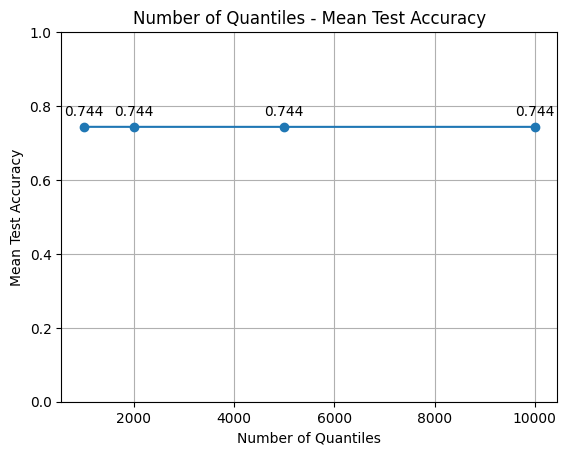

In [38]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("Number of Quantiles")
plt.ylabel("Mean Test Accuracy")
plt.title("Number of Quantiles - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

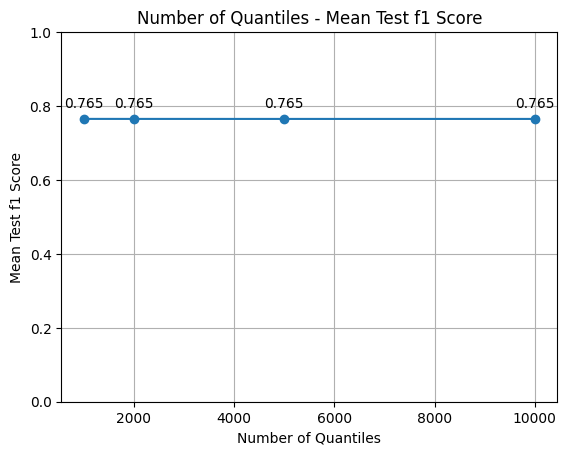

In [39]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_f1"], marker = "o")
plt.xlabel("Number of Quantiles")
plt.ylabel("Mean Test f1 Score")
plt.title("Number of Quantiles - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

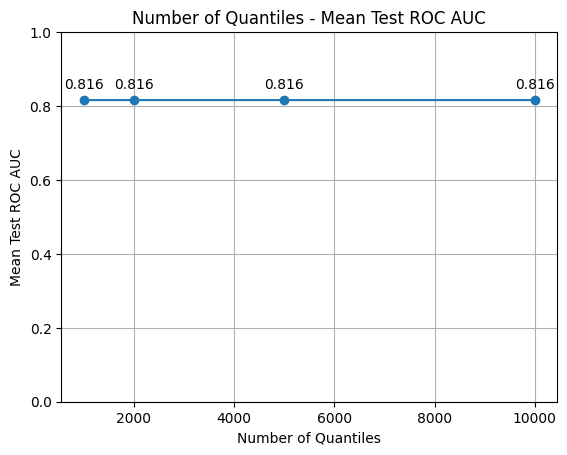

In [40]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("Number of Quantiles")
plt.ylabel("Mean Test ROC AUC")
plt.title("Number of Quantiles - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

### Try Different Scaling Method for Discrete and Ordinal Features 

In [41]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

In [42]:
def power(x, power):
    return x**power

exponential_transformer = FunctionTransformer(power, validate=False)


scaler_pipe = Pipeline ([
    
    ('power', exponential_transformer),
    ('scaler', StandardScaler())            
    
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('exponential_scale', scaler_pipe, ordinal_cols),
        ('bmi_scale', QuantileTransformer(output_distribution = 'uniform') ,bmi_col),
        ("pass_nominal", "passthrough", nominal_cols)
    ],
    remainder='passthrough'
)

model_new = Pipeline([
    ("scaling",preprocessor),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])


In [43]:
param_grid = {
    'scaling__exponential_scale__power__kw_args': [
        {'power': 1.1},
        {'power': 1.3},
        {'power': 1.5},
        {'power': 1.7},
        {'power': 2},
        {'power': 3},
    ]
}

In [44]:
grid = GridSearchCV(model_new, param_grid, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'scaling__exponential_scale__power__kw_args': [{'power': 1.1}, {'power': 1.3}, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('exponential_scale', ...), ('bmi_scale', ...), ...]"


In [45]:
best_scaler_result_df = pd.DataFrame(grid.cv_results_)


In [46]:
best_scaler_model = grid.best_estimator_


In [47]:
grid.best_params_


{'scaling__exponential_scale__power__kw_args': {'power': 1.1}}

In [48]:
best_scaler_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('exponential_scale', ...), ('bmi_scale', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_pred = best_scaler_model.predict(X_test)

In [50]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new


0.7476464802585359

In [51]:
precision_new = precision_score(y_test, y_pred)
precision_new


0.7536627762602434

In [52]:
recall_new = recall_score(y_test, y_pred)
recall_new


0.7905704610575671

In [53]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new


0.771675565725909

In [54]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['First Scaler', 'Improved Scaler ']
)
model_performance_df.head(2)


,Accuracy,precision,recall,f1_score
First Scaler,0.747998,0.753816,0.791222,0.772066
Improved Scaler,0.747646,0.753663,0.790570,0.771676


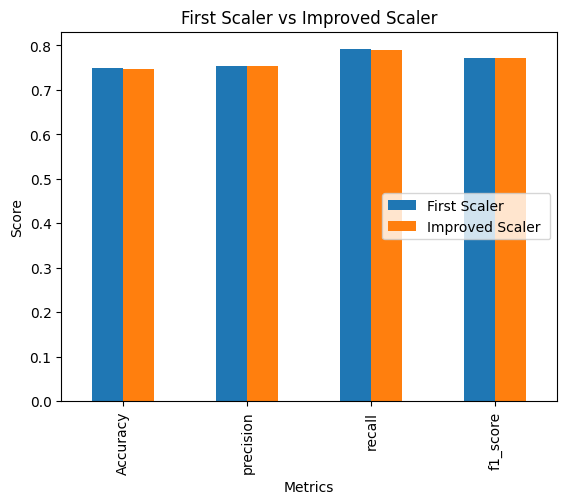

In [55]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("First Scaler vs Improved Scaler")
plt.legend(loc="center right")
plt.show()

In [56]:
best_scaler_result_df["param_scaler_power"] = best_scaler_result_df['param_scaling__exponential_scale__power__kw_args'].apply(lambda d: d["power"])

In [57]:
param_cols =['param_scaler_power']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

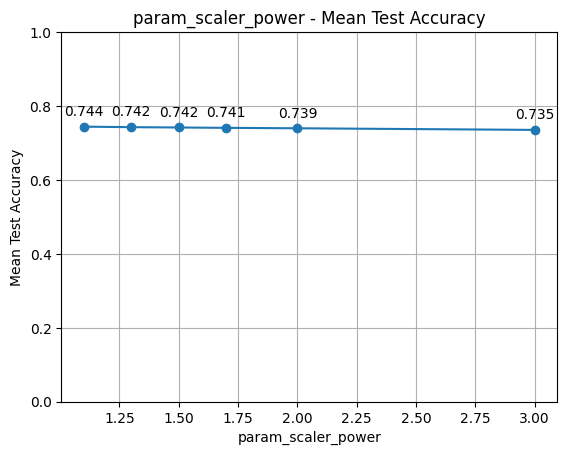

In [58]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test Accuracy")
plt.title("param_scaler_power - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)


for x, y in zip(results["param_scaler_power"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")

plt.show()

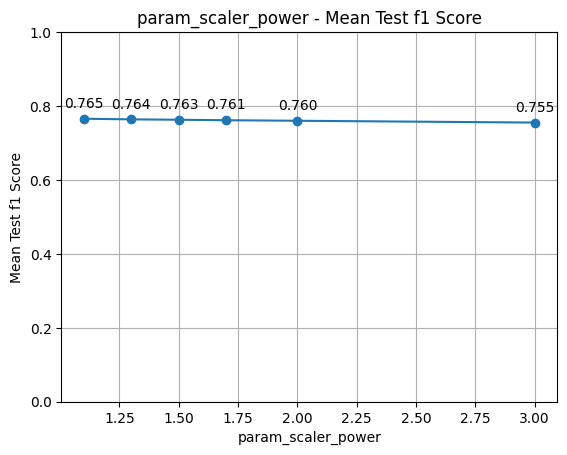

In [59]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test f1 Score")
plt.title("param_scaler_power - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaler_power"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

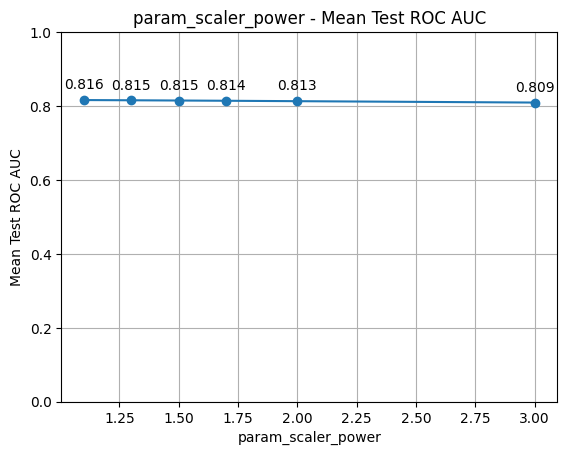

In [60]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_scaler_power - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaler_power"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

## Tolerance's Effect on Model 

In [61]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

In [62]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

best_Transformer = ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )


In [63]:
model_new = Pipeline([
    ("scaling",best_Transformer),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [64]:
param_grids = [
    {
    "model__tol": [1e-3, 1e-4, 1e-5, 1e-6]
    }
]

In [65]:
grid = GridSearchCV(model_new, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'model__tol': [0.001, 0.0001, ...]}]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [66]:
tol_comparison = pd.DataFrame(grid.cv_results_)

In [67]:
best_tol_model = grid.best_estimator_

In [68]:
grid.best_params_

{'model__tol': 0.0001}

In [69]:
best_tol_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Checking Whether the Change in Tolerance Imporved the Model or not

In [70]:
y_pred = best_tol_model.predict(X_test)

In [71]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new

0.7476464802585359

In [72]:
precision_new = precision_score(y_test, y_pred)
precision_new

0.7535998013902682

In [73]:
recall_new = recall_score(y_test, y_pred)
recall_new

0.7907007033081531

In [74]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new

0.7717045887886107

In [75]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['Old Tolerance', 'New Tolerance ']
)

In [76]:
model_performance_df

,Accuracy,precision,recall,f1_score
Old Tolerance,0.747998,0.753816,0.791222,0.772066
New Tolerance,0.747646,0.753600,0.790701,0.771705


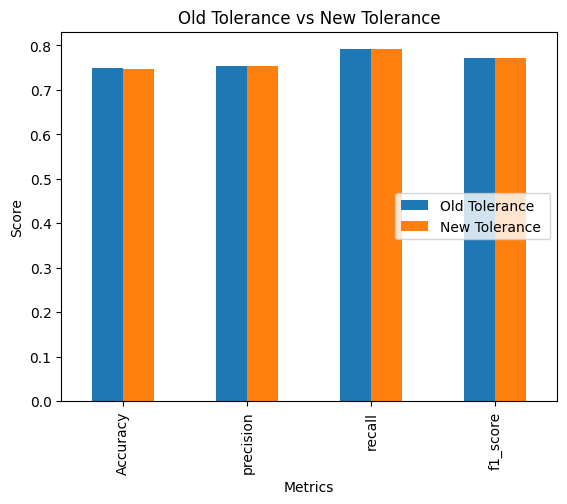

In [77]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Old Tolerance vs New Tolerance")
plt.legend(loc="center right")
plt.show()

### Tolerance's Effect on Model's Success

In [78]:
param_cols =['param_model__tol']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']


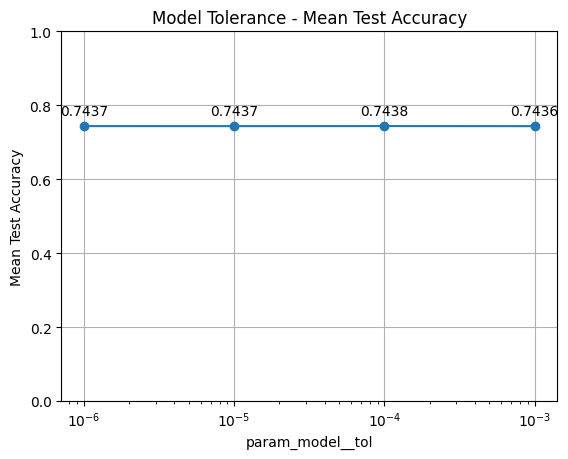

In [79]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test Accuracy")
plt.title("Model Tolerance - Mean Test Accuracy")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)

for x, y in zip(results["param_model__tol"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

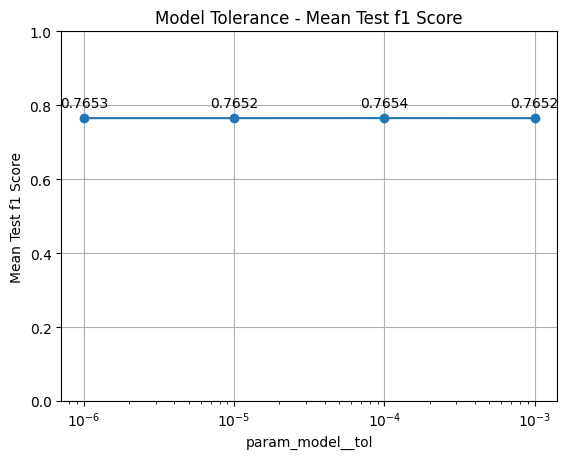

In [80]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test f1 Score")
plt.title("Model Tolerance - Mean Test f1 Score")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)


for x, y in zip(results["param_model__tol"], results["mean_test_f1"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

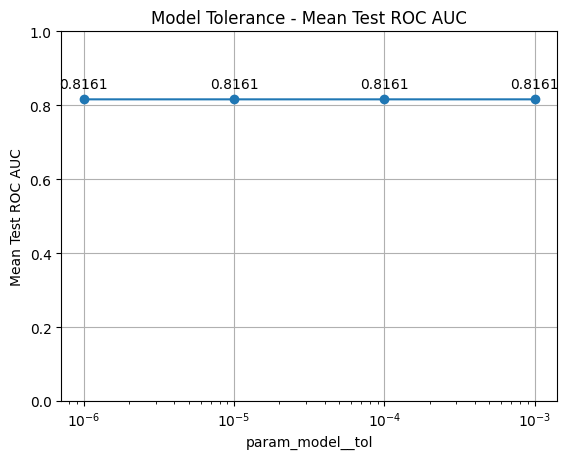

In [81]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test ROC AUC")
plt.title("Model Tolerance - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)


for x, y in zip(results["param_model__tol"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

## PCA (Principal Component Analysis)

In [23]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

scale_step = ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )

pca_pipe = Pipeline(steps=[
    ("preprocess", scale_step),
    ("pca", PCA(svd_solver="auto", random_state=28)),
    ("model",LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

param_grid = {
    "pca__n_components": list(range(1,23))
}


In [24]:

grid = GridSearchCV(pca_pipe, param_grid, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv=5, refit="f1")
grid.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'pca__n_components': [1, 2, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


### Analyzing the Result of PCA

In [ ]:
#pca_df = pd.DataFrame(grid.cv_results_)
#pca_df.to_csv("pca_results.csv", index=False)

In [25]:
best_model_pca = grid.best_estimator_

In [10]:
### Trying best model with current test split (%80 train/ %20 test)
y_pred = best_model_pca.predict(X_test)

In [26]:
best_model1.named_steps["model"].n_iter_

array([5], dtype=int32)

In [27]:
accuracy_pca = accuracy_score(y_test, y_pred)
accuracy_pca

0.7479977518617394

In [28]:
precision_pca = precision_score(y_test, y_pred)
precision_pca

0.753815609877156

In [29]:
recall_pca = recall_score(y_test, y_pred)
recall_pca

0.7912216723104976

In [30]:
f1_score_pca = f1_score(y_test, y_pred)
f1_score_pca

0.7720658321153968

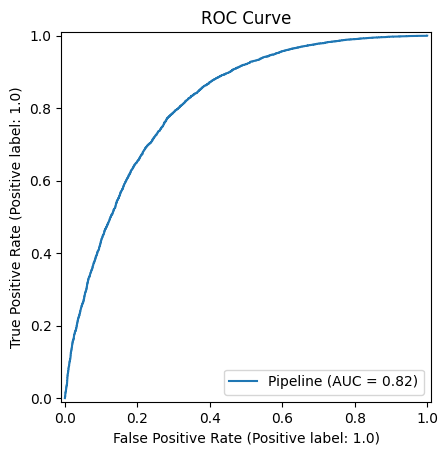

In [31]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


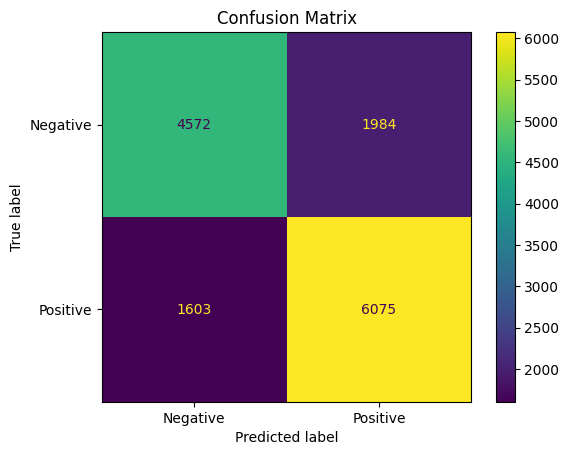

In [32]:

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [33]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_pca, precision_pca, recall_pca, f1_score_pca]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['model_without_pca', 'model_with_pca']
)

model_performance_df.head(2)

,Accuracy,precision,recall,f1_score
model_without_pca,0.747998,0.753816,0.791222,0.772066
model_with_pca,0.747998,0.753816,0.791222,0.772066


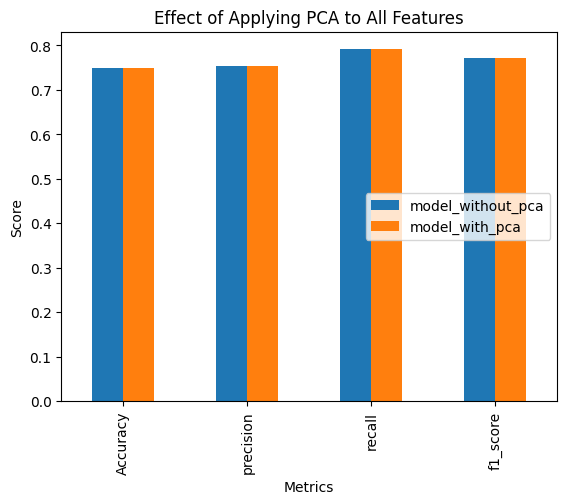

In [34]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Effect of Applying PCA to All Features")
plt.legend(loc="center right")
plt.show()

In [36]:
pca_df = pd.read_csv("pca_results.csv")
pca_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_pca__n_components,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,0.044190,0.011553,0.021171,0.003359,1,{'pca__n_components': 1},0.565486,0.562924,0.563185,0.561010,0.566580,...,0.538173,0.003599,22,0.626229,0.619418,0.624702,0.622295,0.629962,0.624521,0.003565,22
1,0.043557,0.002464,0.021600,0.002674,2,{'pca__n_components': 2},0.616831,0.612185,0.620104,0.615492,0.628721,...,0.579005,0.006549,21,0.706175,0.703602,0.706574,0.706163,0.715421,0.707587,0.004057,21
2,0.045666,0.004279,0.026330,0.003136,3,{'pca__n_components': 3},0.696023,0.700870,0.700609,0.699130,0.701305,...,0.728054,0.002631,19,0.757657,0.763852,0.761969,0.761337,0.762771,0.761517,0.002105,20
3,0.050531,0.005237,0.027354,0.005608,4,{'pca__n_components': 4},0.695501,0.703916,0.703655,0.700174,0.701915,...,0.727865,0.003415,20,0.759760,0.765564,0.764938,0.763726,0.764935,0.763785,0.002099,19
4,0.053307,0.005203,0.024903,0.004603,5,{'pca__n_components': 5},0.713950,0.718451,0.718799,0.714360,0.719495,...,0.740351,0.003080,18,0.775936,0.781354,0.780035,0.782505,0.786079,0.781182,0.003304,18


In [37]:
param_cols = ['param_pca__n_components']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [38]:
pca_df[std_cols].describe()

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.007726,0.004214,0.003480,0.002861,0.006624,0.003930,0.003910
std,0.004034,0.002038,0.000900,0.001377,0.000879,0.000859,0.000657
min,0.002464,0.001842,0.001926,0.001067,0.005140,0.002631,0.002099
25%,0.005211,0.002826,0.003117,0.002059,0.006049,0.003437,0.003874
50%,0.006998,0.003492,0.003410,0.002758,0.006331,0.003789,0.004102
75%,0.009436,0.005732,0.003732,0.003389,0.007285,0.004164,0.004263
max,0.017223,0.010303,0.005632,0.007966,0.008304,0.006549,0.004595


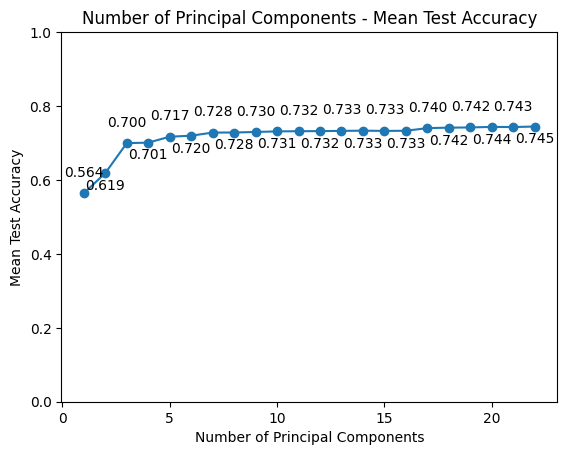

In [40]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_accuracy"].mean().reset_index()

plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_accuracy"], marker = "o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Test Accuracy")
plt.title("Number of Principal Components - Mean Test Accuracy")
plt.ylim(0, 1)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

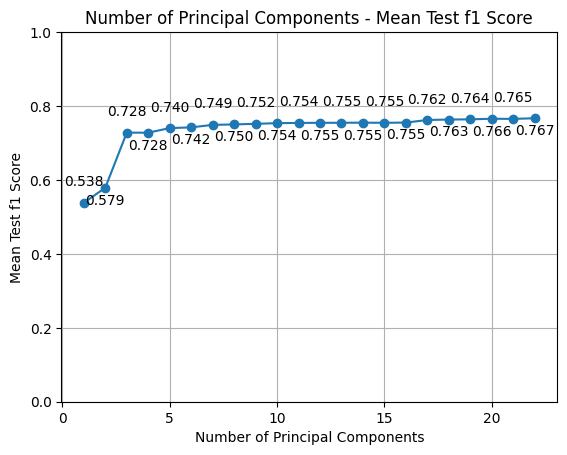

In [41]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_f1"].mean().reset_index()
results_pca.head()


plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_f1"], marker = "o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Test f1 Score")
plt.title("Number of Principal Components - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

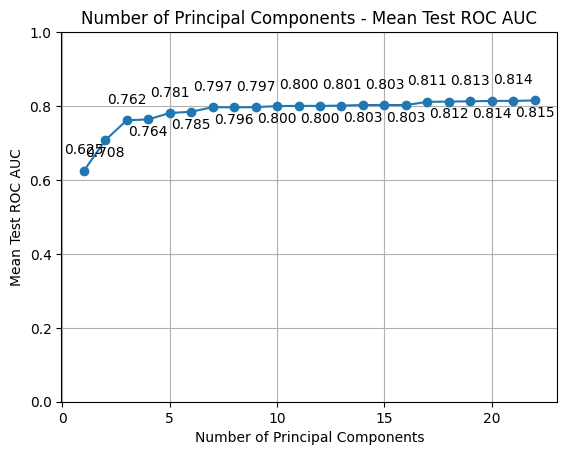

In [42]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_roc_auc"].mean().reset_index()
results_pca.head()


plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_roc_auc"], marker = "o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Test ROC AUC")
plt.title("Number of Principal Components - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

In [43]:
best_pca = grid.best_estimator_.named_steps["pca"]

In [44]:
best_pca.n_components

22

In [45]:
best_pca.explained_variance_

array([3.96713446, 1.90552923, 0.69786138, 0.42917869, 0.28592764,
       0.25437937, 0.21263735, 0.1940755 , 0.16625468, 0.15716555,
       0.14333479, 0.13269507, 0.11095318, 0.10342695, 0.07221427,
       0.07054474, 0.06866568, 0.06380883, 0.0539269 , 0.0450305 ,
       0.02723491, 0.01955932])

In [46]:
best_pca.mean_

array([-0.06872629,  0.88257693,  0.96246956, -0.08115252,  0.03273851,
       -0.04464662,  0.50398327,  0.08855557,  0.56772517,  0.52183153,
        0.97843192,  0.16732823,  0.10229029,  0.42249192,  0.0640895 ,
        0.13898061,  0.04891457,  0.96835043,  0.07543558,  0.23069763,
        0.50288043,  0.7111318 ])

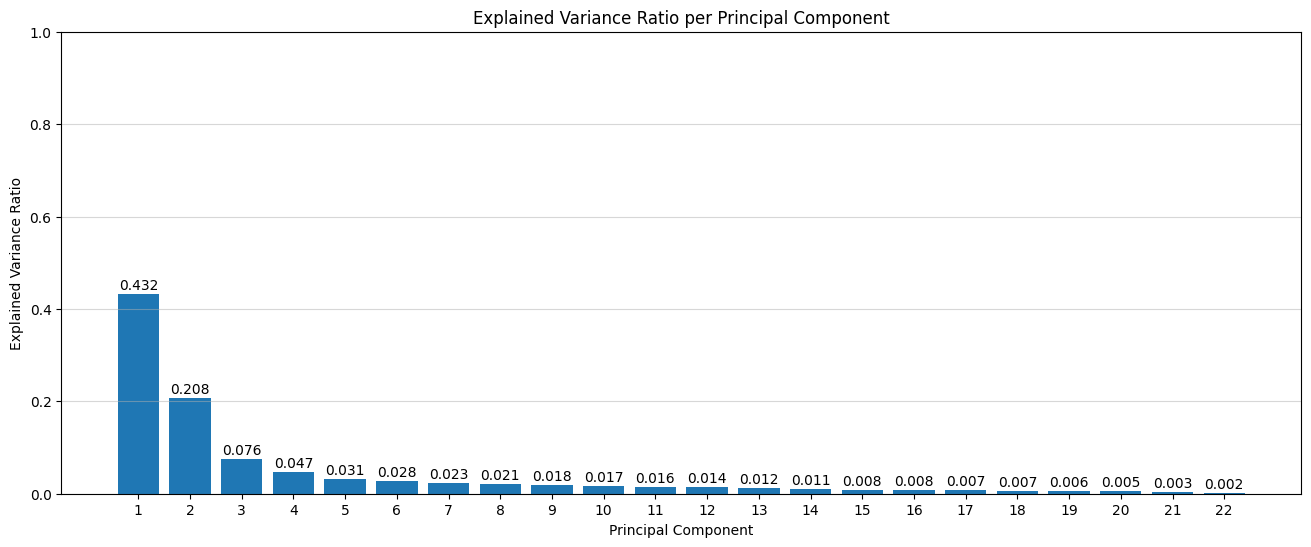

In [47]:
plt.figure(figsize=(16,6))
bars = plt.bar(range(1, 23), best_pca.explained_variance_ratio_)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.3f}", ha='center')

plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 23))
plt.ylim(0, 1)
plt.grid(axis='y', alpha = 0.5)
plt.show()

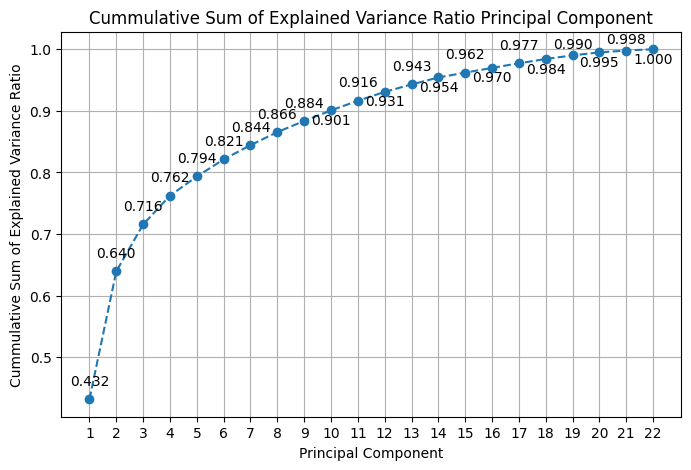

In [49]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 23), best_pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cummulative Sum of Explained Variance Ratio Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Cummulative Sum of Explained Variance Ratio')
plt.xticks(range(1, 23))
plt.grid(True)

offsets = [10, 10, 10, 10, 10, 10, 10, 10, 10, -10, 10, -10, 10, -10, 10, -10, 10, -10, 5, -10, 5, -10]
i = 0
for x, y in zip(range(1, 23), best_pca.explained_variance_ratio_.cumsum()):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1

plt.show()

In [201]:
best_pca.noise_variance_

0.0

In [202]:
#DF that shows the how every component constructed from original features

component_df = pd.DataFrame(
    best_pca.components_,
    columns= [  'KidneyDisease', 'HighBP', 'HighChol', 'CholCheck',
                'Asthma', 'COPD', 'BMI', 'Smoker', 'Stroke', 
                'HeartDiseaseorAttack','PhysActivity', 'HvyAlcoholConsump', 
                'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 
                'PhysHlth', 'DiffWalk', 'Sex', 'AgeGroup','Education', 'Income'],
    index=[f"PC{i+1}" for i in range(best_pca.n_components_)]
)

component_df.head(22)

,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
PC1,0.147873,0.692037,0.682413,-0.012776,-0.041426,-0.094936,0.022845,0.028330,0.031861,0.028251,0.000619,0.036850,0.043285,0.034358,0.017648,0.029372,-0.000276,-0.002426,0.028485,0.091905,-0.023918,-0.063862
PC2,-0.100958,0.702067,-0.656555,-0.197773,0.031293,0.051624,-0.010499,-0.037143,-0.068199,-0.044298,-0.006817,-0.005152,-0.034065,-0.021939,-0.017571,-0.040942,0.010776,-0.006678,0.014644,-0.086129,-0.019855,0.055645
PC3,0.165075,0.109702,-0.263112,0.735107,-0.148973,-0.286123,0.029228,0.115686,0.304235,0.233528,0.018328,0.004120,0.101198,0.136903,0.047396,0.118741,-0.014277,0.019139,-0.020899,0.144500,-0.010617,-0.134284
PC4,-0.191587,0.110812,0.107782,0.443975,0.459159,0.638809,-0.066670,-0.022569,0.041586,0.098635,0.014678,-0.139558,-0.112574,-0.084363,-0.011625,0.008052,0.007821,0.052204,-0.084448,-0.098117,0.138949,0.168625
PC5,0.215498,-0.025775,-0.056641,-0.317930,-0.000959,0.260367,0.103875,0.243137,0.279925,0.282089,0.000293,0.197804,0.255394,0.331149,0.023226,0.132234,0.020450,-0.003675,0.016093,-0.000823,0.565210,0.028067
PC6,0.044351,-0.023949,-0.037907,-0.042280,0.266210,0.101315,0.045866,0.416012,0.043328,0.101174,0.013418,0.579213,0.239694,-0.333174,0.009644,-0.011772,-0.018351,0.023539,-0.002795,0.077733,-0.463025,-0.011377
PC7,0.107621,-0.000237,-0.010051,-0.135711,-0.037168,-0.055325,0.043453,0.655427,0.148601,0.077318,0.003139,-0.449934,-0.449130,-0.312279,0.007515,0.016778,-0.021094,-0.009850,0.009098,0.010716,0.046099,-0.032173
PC8,0.148536,-0.020654,-0.009760,-0.183715,0.019154,0.000889,0.138269,-0.533766,0.384123,0.537969,0.019723,0.032173,-0.248697,-0.355166,-0.003006,-0.020954,-0.017615,-0.004275,0.019914,-0.010477,-0.100646,-0.038494
PC9,-0.050999,-0.028951,0.011752,-0.141827,0.058854,0.120212,-0.020060,0.091622,-0.097935,0.437651,0.008213,-0.310977,0.034719,0.578519,-0.018714,-0.040804,0.039362,0.007099,0.002326,-0.033789,-0.557176,-0.024406
PC10,-0.311664,0.012285,0.085864,0.065059,-0.096932,-0.330546,-0.139228,0.123024,-0.117544,0.330935,-0.003292,0.301259,-0.255791,0.075971,-0.015678,-0.017261,0.001146,-0.013089,0.017683,-0.233856,0.121060,0.618270


In [ ]:
component_df.to_csv("component_pca.csv", index=False)

In [86]:
component_df = pd.read_csv("component_pca.csv")

In [87]:
component_df_percent = component_df.abs().div(component_df.abs().sum(axis=1), axis=0) * 100
component_df_percent

,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
0,6.859472,32.101903,31.655442,0.592625,1.921641,4.403828,1.059735,1.314164,1.477933,1.310501,0.028735,1.709362,2.007895,1.593800,0.818656,1.362499,0.012786,0.112554,1.321358,4.263252,1.109478,2.962381
1,4.546372,31.615815,29.566304,8.906217,1.409181,2.324735,0.472813,1.672622,3.071153,1.994865,0.306985,0.231993,1.534028,0.987966,0.791271,1.843715,0.485265,0.300717,0.659457,3.878595,0.894099,2.505833
2,5.221974,3.470312,8.323233,23.254288,4.712584,9.051161,0.924586,3.659608,9.624143,7.387382,0.579779,0.130332,3.201277,4.330758,1.499322,3.756222,0.451643,0.605425,0.661108,4.571107,0.335847,4.247912
3,6.175050,3.571577,3.473933,14.309781,14.799175,20.589502,2.148841,0.727424,1.340364,3.179123,0.473091,4.498106,3.628373,2.719119,0.374697,0.259510,0.252065,1.682579,2.721838,3.162430,4.478467,5.434955
4,6.412470,0.766977,1.685422,9.460484,0.028545,7.747598,3.090963,7.234905,8.329570,8.393968,0.008707,5.885937,7.599621,9.853821,0.691137,3.934820,0.608522,0.109355,0.478858,0.024503,16.818637,0.835182
5,1.526109,0.824084,1.304395,1.454852,9.160306,3.486253,1.578264,14.314992,1.490935,3.481394,0.461705,19.930745,8.247876,11.464530,0.331866,0.405066,0.631456,0.809989,0.096185,2.674787,15.932738,0.391471
6,4.078532,0.008979,0.380917,5.143061,1.408581,2.096657,1.646741,24.838834,5.631568,2.930141,0.118978,17.051241,17.020748,11.834492,0.284807,0.635831,0.799402,0.373277,0.344790,0.406104,1.747036,1.219284
7,5.215486,0.725226,0.342705,6.450729,0.672566,0.031208,4.854987,18.741964,13.487580,18.889551,0.692530,1.129693,8.732406,12.470825,0.105551,0.735737,0.618493,0.150109,0.699235,0.367866,3.533940,1.351613
8,1.877747,1.065961,0.432691,5.221979,2.166977,4.426131,0.738583,3.373462,3.605906,16.113978,0.302405,11.449937,1.278346,21.300633,0.689051,1.502374,1.449297,0.261397,0.085641,1.244078,20.514815,0.898611
9,9.480453,0.373683,2.611869,1.979017,2.948574,10.054819,4.235163,3.742237,3.575561,10.066662,0.100134,9.163955,7.780867,2.310938,0.476911,0.525062,0.034865,0.398150,0.537893,7.113641,3.682500,18.807045


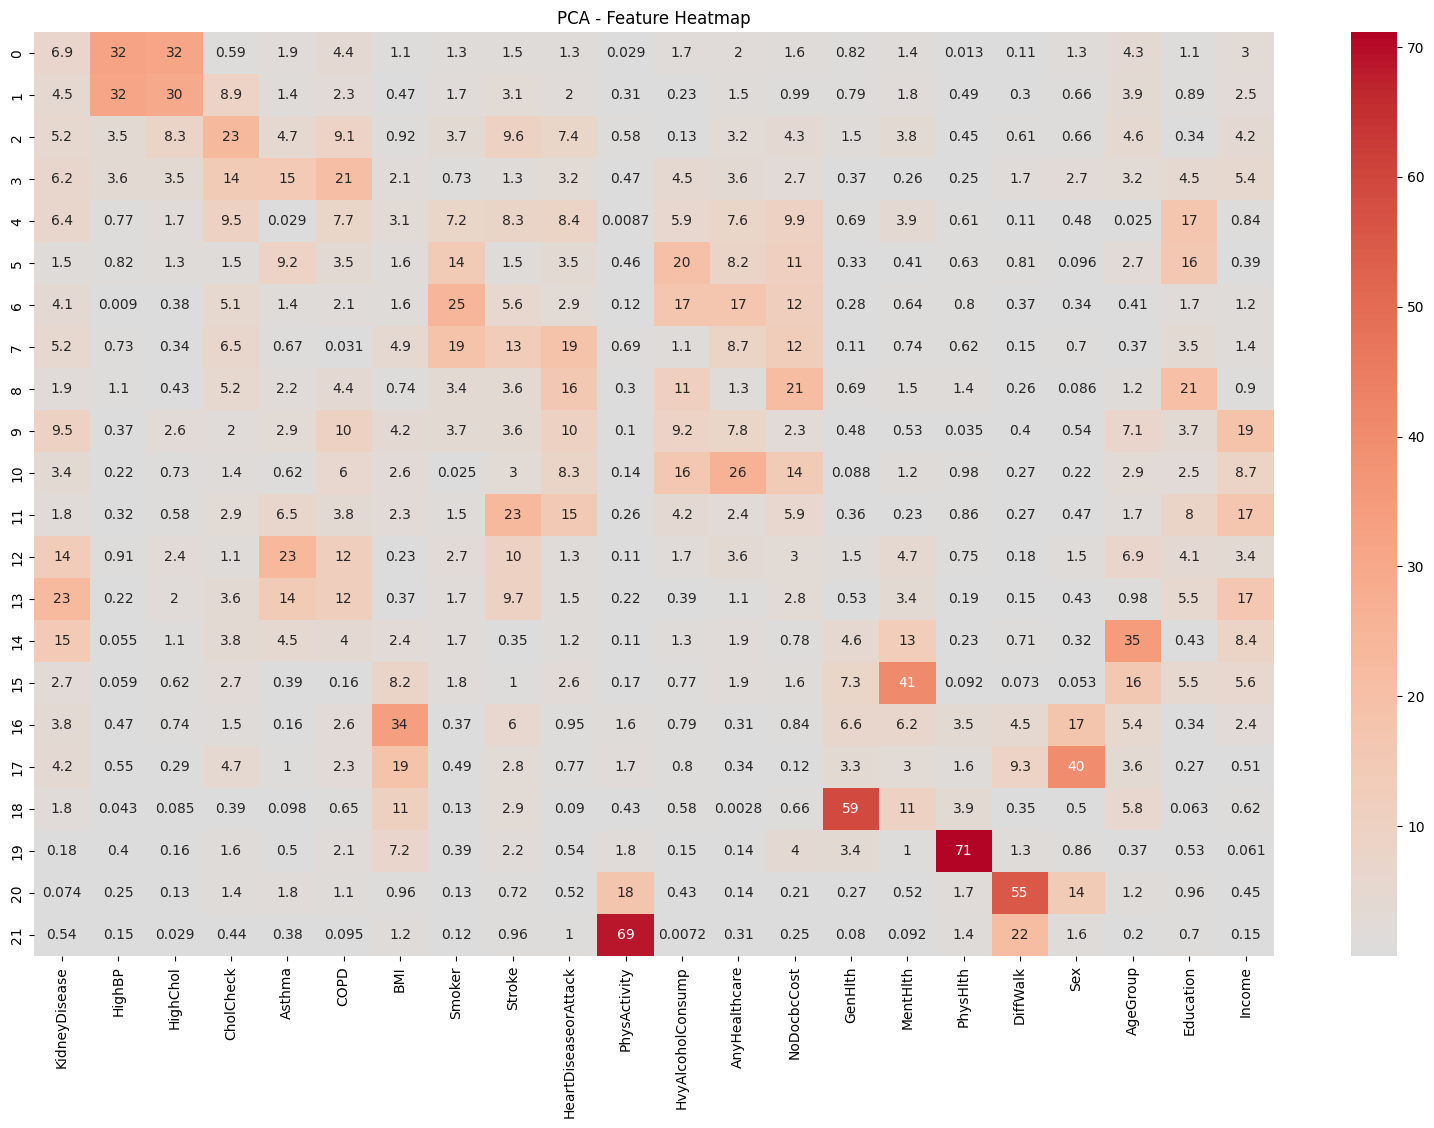

In [89]:
plt.figure(figsize=(20, 12))
sns.heatmap(component_df_percent, annot=True, cmap="coolwarm", center=0)
plt.title("PCA - Feature Heatmap")
plt.show()

## Applying PCA to Spesific Columns Instead of Entire Dataset

In [55]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
ordinal_cols_1 = ['GenHlth','MentHlth','PhysHlth','AgeGroup']
ordinal_cols_2 = ['GenHlth','AgeGroup','Education','Income']
ordinal_cols_3 = ['GenHlth','AgeGroup']
bmi_col = ['BMI']

pca_cols1 = ['Education','Income']
pca_cols2 = ['MentHlth','PhysHlth']

# pca pipes
pca_pipe1 = Pipeline([
    ("scale_pca",RobustScaler()),
    ("pca", PCA(n_components=1))
])

pca_pipe2 = Pipeline([
    ("scale_pca",RobustScaler()),
    ("pca", PCA(n_components=1))
])

# pca transformers 
pca_transformer1 = ColumnTransformer(
    transformers= [
        ("ordinal_scaler",RobustScaler(), ordinal_cols_1),
        ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
        ("pass_nominal", "passthrough", nominal_cols),
        ("pca_trans1", pca_pipe1, pca_cols1)    
    ],
    remainder="passthrough"
)

pca_transformer2 = ColumnTransformer(
    transformers= [
        ("ordinal_scaler",RobustScaler(), ordinal_cols_2),
        ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
        ("pass_nominal", "passthrough", nominal_cols),
        ("pca_trans2", pca_pipe2, pca_cols2)    
    ],
    remainder="passthrough"
)


pca_transformer3 = ColumnTransformer(
    transformers= [
        ("ordinal_scaler",RobustScaler(), ordinal_cols_3),
        ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
        ("pass_nominal", "passthrough", nominal_cols),
        ("pca_trans3", pca_pipe1, pca_cols1),
        ("pca_trans4", pca_pipe2, pca_cols2)    
    ],
    remainder="passthrough"
)

#model pipe
model_pca = Pipeline([
    ("preprocessing",None),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

# hyperparamter combination which is going to be experimented in grid search
param_grids = [
    {
    "preprocessing": [pca_transformer1, pca_transformer2, pca_transformer3]
    }
]

In [56]:
grid = GridSearchCV(model_pca, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'preprocessing': [ColumnTransfo..., 'Income'])]), ColumnTransfo...'PhysHlth'])]), ...]}]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [57]:
partial_pca_res = pd.DataFrame(grid.cv_results_)

In [58]:
partial_pca_model = grid.best_estimator_

In [59]:
grid.best_params_

{'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('ordinal_scaler', RobustScaler(),
                                  ['GenHlth', 'AgeGroup']),
                                 ('bmi_scaler', QuantileTransformer(), ['BMI']),
                                 ('pass_nominal', 'passthrough',
                                  ['KidneyDisease', 'HighBP', 'HighChol',
                                   'CholCheck', 'Asthma', 'COPD', 'Smoker',
                                   'Stroke', 'HeartDiseaseorAttack',
                                   'HvyAlcoholConsump', 'AnyHealthcare',
                                   'NoDocbcCost', 'DiffWalk', 'Sex']),
                                 ('pca_trans3',
                                  Pipeline(steps=[('scale_pca', RobustScaler()),
                                                  ('pca', PCA(n_components=1))]),
                                  ['Education', 'Income']),
                               

In [60]:
partial_pca_model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
param_cols =['pca_type']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [62]:
def pca_extractor(s):
    col_trans_str = str(s)
    pattern = r"pca_trans(\d)"
    ans = re.search(pattern, col_trans_str)
    if ans:
        num = ans.group(1)
        if num == '1':
            return "Income- Education"
        elif num == '2':
            return "Pyhsical - Mental Health"
        else:
            return "Seperate PCA's for both pair"

In [63]:
partial_pca_res["pca_type"] = partial_pca_res['param_preprocessing'].apply(pca_extractor)

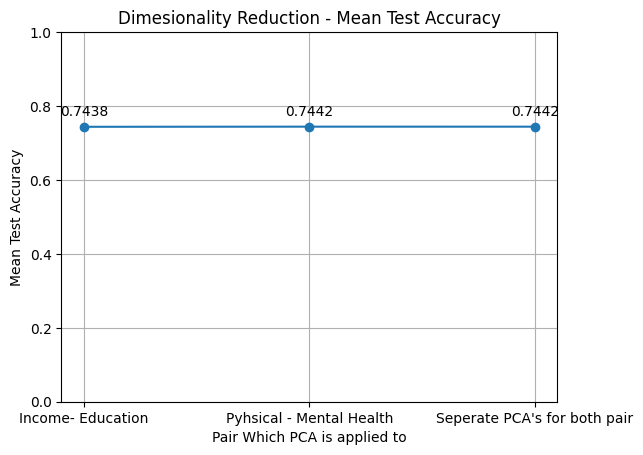

In [64]:
results = partial_pca_res[param_cols + mean_cols]

results = results.groupby("pca_type")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["pca_type"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("Pair Which PCA is applied to")
plt.ylabel("Mean Test Accuracy")
plt.title("Dimesionality Reduction - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["pca_type"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

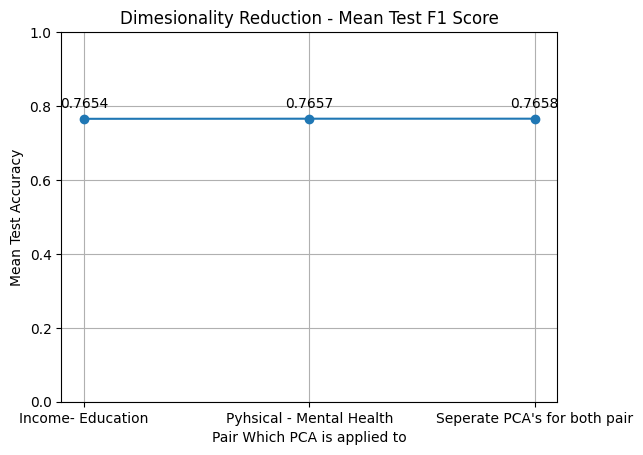

In [67]:
results = partial_pca_res[param_cols + mean_cols]

results = results.groupby("pca_type")["mean_test_f1"].mean().reset_index()



plt.plot(results["pca_type"], results["mean_test_f1"], marker= "o")
plt.xlabel("Pair Which PCA is applied to")
plt.ylabel("Mean Test Accuracy")
plt.title("Dimesionality Reduction - Mean Test F1 Score")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["pca_type"], results["mean_test_f1"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

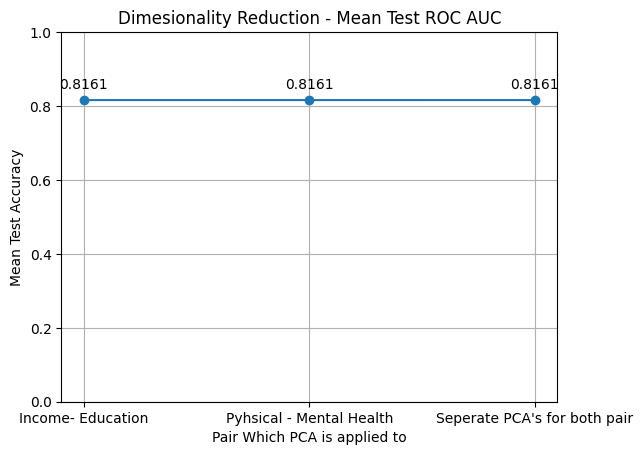

In [68]:
results = partial_pca_res[param_cols + mean_cols]

results = results.groupby("pca_type")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["pca_type"], results["mean_test_roc_auc"], marker= "o")
plt.xlabel("Pair Which PCA is applied to")
plt.ylabel("Mean Test Accuracy")
plt.title("Dimesionality Reduction - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["pca_type"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.4f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

### Observing Whether The Dimensionality Reduction for This Spesific Features Improve the Model or not

In [69]:
y_pred = partial_pca_model.predict(X_test)

In [70]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new

0.7481382605030209

In [71]:
precision_new = precision_score(y_test, y_pred)
precision_new

0.7540657976412166

In [72]:
recall_new = recall_score(y_test, y_pred)
recall_new

0.7910914300599114

In [73]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new

0.7721350028602301

In [74]:

pca_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['Before Feature Extraction', 'After Feature Extraction']
)

In [75]:
pca_performance_df


,Accuracy,precision,recall,f1_score
Before Feature Extraction,0.747998,0.753816,0.791222,0.772066
After Feature Extraction,0.748138,0.754066,0.791091,0.772135


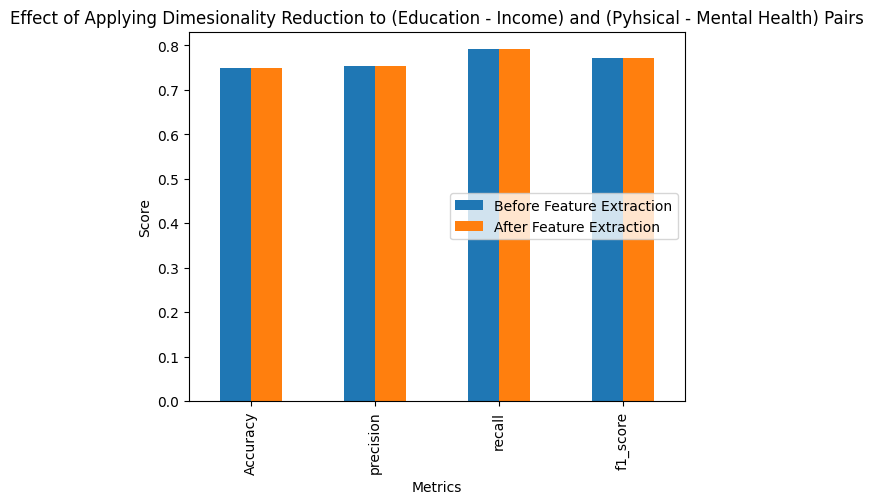

In [76]:

pca_performance_df_T = pca_performance_df.T
pca_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Effect of Applying Dimesionality Reduction to (Education - Income) and (Pyhsical - Mental Health) Pairs")
plt.legend(loc="center right")
plt.show()

## Deleting Outliers
- Delete datapoints who has a BMI more than 60 or less than 11 (BMI = Body Mass Index)

In [77]:
df = df[(df["BMI"] >= 11) & (df["BMI"] <= 60)]

df.shape

(70953, 23)

In [78]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x1bd5fe03b20>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

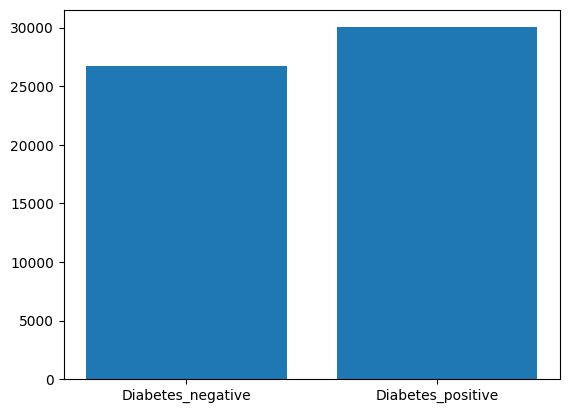

In [79]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x1bd5fde4550>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

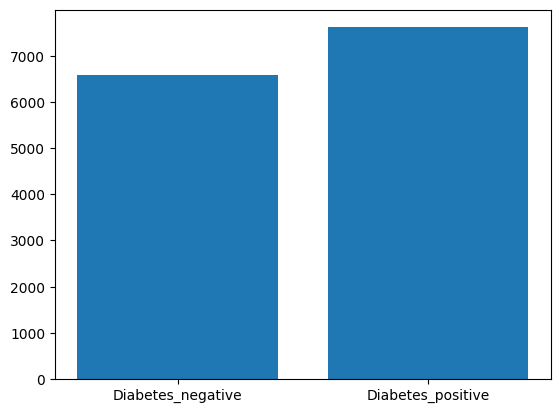

In [80]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

In [81]:
best_model1.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
y_pred = best_model1.predict(X_test)

In [83]:
accuracy_del = accuracy_score(y_test, y_pred)
precision_del = precision_score(y_test, y_pred)
recall_del = recall_score(y_test, y_pred)
f1_score_del = f1_score(y_test, y_pred)

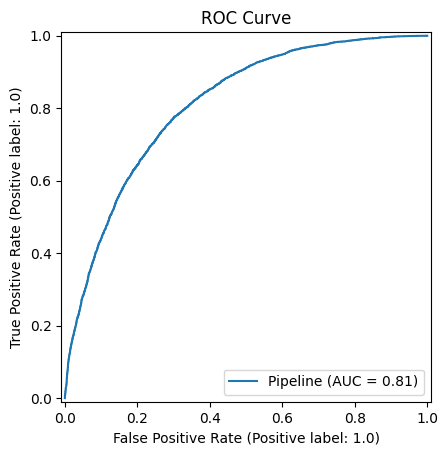

In [84]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()

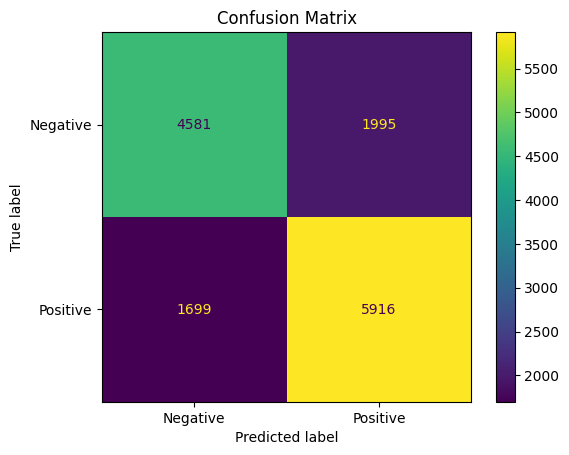

In [85]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [86]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_del, precision_del, recall_del, f1_score_del]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['with_outliers', 'without_outliers']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
with_outliers,0.747998,0.753816,0.791222,0.772066
without_outliers,0.739694,0.747819,0.776888,0.762077


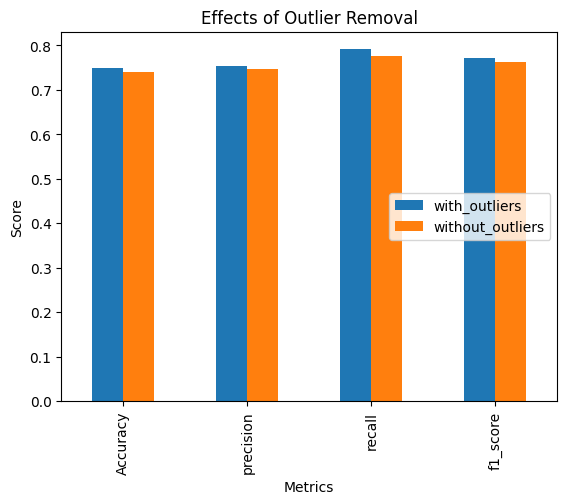

In [87]:
best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Effects of Outlier Removal")
plt.legend(loc="center right")
plt.show()

In [88]:
# Bringing dataframe to it's initial version since removing outliers cause decrease in success metrics
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2023.csv')
df.loc[df['KidneyDisease'] == 2, 'KidneyDisease'] = 0
df.loc[df['Asthma'] == 2, 'Asthma'] = 0
df.loc[df['COPD'] == 2, 'COPD'] = 0
df = df[df['KidneyDisease'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['Asthma'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['COPD'].isin([0.0,1.0])].reset_index(drop=True)

In [139]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model.pkl')

## Trying Feature Removal

### Measuring The Importance of the Features

In [4]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

In [7]:
best_model1.fit(X_train, y_train)
r = permutation_importance(best_model1, X_test, y_test, n_repeats=10)

imp = pd.DataFrame({'feature': best_model1.feature_names_in_, 'importance': r.importances_mean}).sort_values("importance", ascending=False)

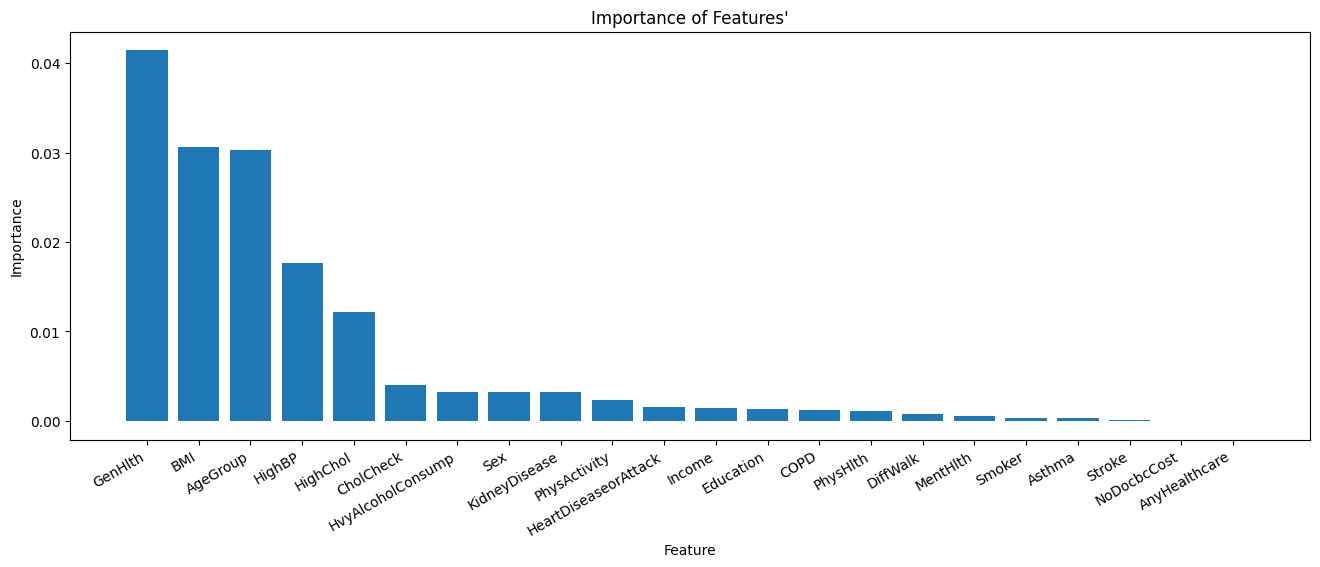

In [8]:
plt.figure(figsize=(16, 6))
plt.bar(imp["feature"], imp["importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Importance of Features'")

plt.gcf().autofmt_xdate()
plt.show()

In [9]:
nominal_cols.remove('AnyHealthcare')
remove_1_feature = ColumnTransformer( #without less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal1", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('NoDocbcCost')
remove_2_feature = ColumnTransformer( #without 2 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal2", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

ordinal_cols.remove('MentHlth')
remove_3_feature = ColumnTransformer( #without 3 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal3", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Stroke')
remove_4_feature = ColumnTransformer( #without 4 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal4", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Smoker')
remove_5_feature = ColumnTransformer( #without 5 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal5", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Asthma')
remove_6_feature = ColumnTransformer( #without 6 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal6", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

feature_removals = [remove_1_feature, remove_2_feature, remove_3_feature, remove_4_feature, remove_5_feature, remove_6_feature]

In [10]:
pipe_feature_removal = Pipeline([
    ("scaling",StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [11]:
param_grids = {
    'scaling': feature_removals
}

grid = GridSearchCV(pipe_feature_removal, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'scaling': [ColumnTransfo...lk', 'Sex'])]), ColumnTransfo...lk', 'Sex'])]), ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [12]:
best_removal_model = grid.best_estimator_

In [13]:
grid.best_params_

{'scaling': ColumnTransformer(transformers=[('ordinal_scaler', RobustScaler(),
                                  ['GenHlth', 'PhysHlth', 'AgeGroup',
                                   'Education', 'Income']),
                                 ('bmi_scaler', QuantileTransformer(), ['BMI']),
                                 ('pass_nominal1', 'passthrough',
                                  ['KidneyDisease', 'HighBP', 'HighChol',
                                   'CholCheck', 'COPD', 'HeartDiseaseorAttack',
                                   'HvyAlcoholConsump', 'DiffWalk', 'Sex'])])}

In [14]:
removal_results_df = pd.DataFrame(grid.cv_results_)

### Observing Effects of Feature Removal

In [15]:
def how_many_removal(s):
    col_trans_str = str(s)
    pattern = r"pass_nominal(\d)"
    ans = re.search(pattern, col_trans_str)
    if ans:
        return (ans.group(1))

In [16]:
param_cols =['number_of_removed_features']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

removal_results_df["number_of_removed_features"] = removal_results_df["param_scaling"].apply(how_many_removal)

In [17]:
results_df = removal_results_df[param_cols + mean_cols]
results_df

,number_of_removed_features,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
0,1,0.362597,0.057411,0.742413,0.741223,0.788778,0.764252,0.814995
1,2,0.375529,0.065893,0.742255,0.741075,0.788646,0.764111,0.815005
2,3,0.352572,0.061426,0.742219,0.741058,0.788579,0.764071,0.815010
3,4,0.400940,0.057597,0.742202,0.741051,0.788546,0.764052,0.815005
4,5,0.354199,0.052258,0.742149,0.740982,0.788546,0.764015,0.814997
5,6,0.268858,0.033643,0.742149,0.740982,0.788546,0.764014,0.814997


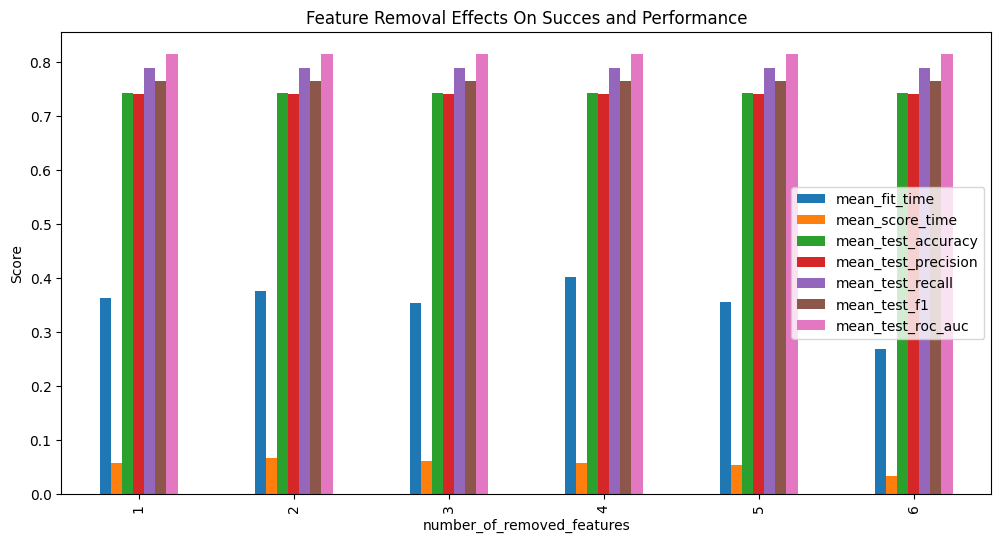

In [18]:
results_df.plot(x="number_of_removed_features" ,kind="bar", figsize=(12,6))
plt.xlabel("number_of_removed_features")
plt.ylabel("Score")
plt.title("Feature Removal Effects On Succes and Performance")
plt.legend(loc="center right")

plt.show()

### Compare Feature Removal Model's Success with First Model's Success

In [38]:
best_removal_model.fit(X_train,y_train)

y_pred = best_removal_model.predict(X_test)

accuracy_new = accuracy_score(y_test, y_pred)
precision_new = precision_score(y_test, y_pred)
recall_new = recall_score(y_test, y_pred)
f1_score_new = f1_score(y_test, y_pred)

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model_1', 'model_without_AnyHealthCare ']
)

In [137]:
model_performance_df

,Accuracy,precision,recall,f1_score
best_model_1,0.747998,0.753816,0.791222,0.772066
model_without_AnyHealthCare,0.744555,0.750620,0.788356,0.769026


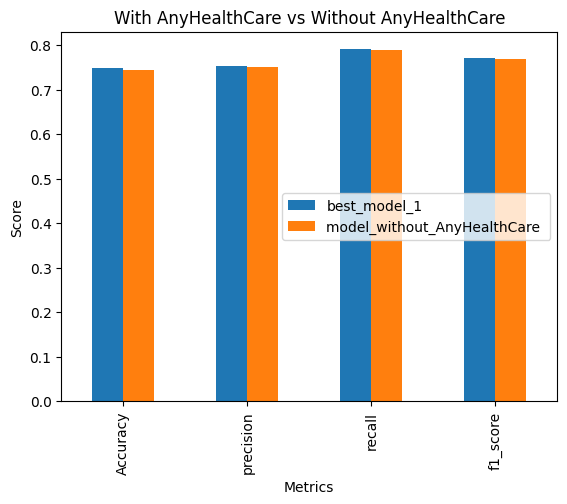

In [39]:
model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("With AnyHealthCare vs Without AnyHealthCare")
plt.legend(loc="center right")
plt.show()

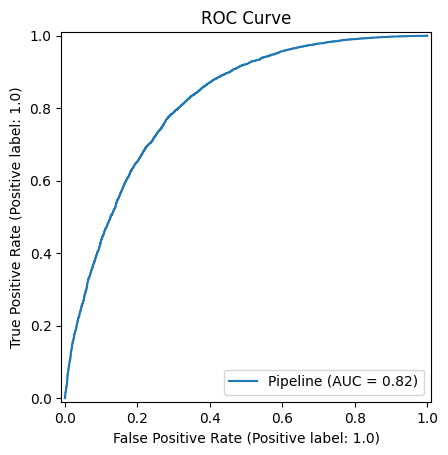

In [40]:

RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()

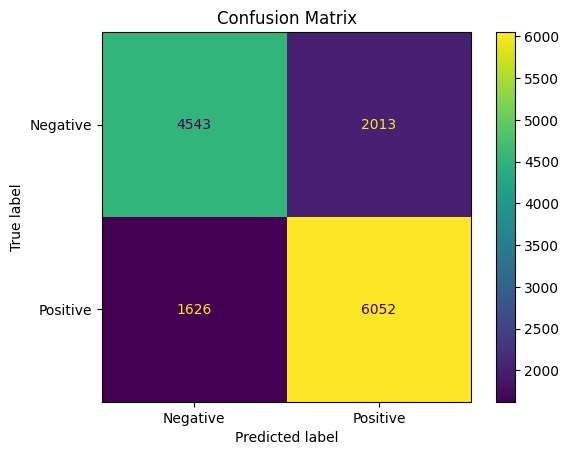

In [41]:

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

# Final Succes Metrics and Model's Consistency

In [140]:
final_results = []

for i in range(0,20):
    y = df["Diabetes_binary"] #label
    X = df.drop("Diabetes_binary", axis=1) # feature

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = i)

    best_model1.fit(X_train,y_train)
    y_pred = best_model1.predict(X_test)


    #### Succes Metrics
    accuracy_i = accuracy_score(y_test, y_pred)
    precision_i = precision_score(y_test, y_pred)
    recall_i = recall_score(y_test, y_pred)
    f1_score_i = f1_score(y_test, y_pred)

    final_results.append({
                    "accuracy": accuracy_i,
                    "precision": precision_i,
                    "recall": recall_i,
                    "f1_score": f1_score_i  
                    })
    

final_results_df = pd.DataFrame(final_results)

In [141]:
final_results_df.describe()

,accuracy,precision,recall,f1_score
count,20.000000,20.000000,20.000000,20.000000
mean,0.745051,0.743581,0.793730,0.767821
std,0.003844,0.005095,0.005750,0.004039
min,0.738584,0.732801,0.778810,0.759495
25%,0.742184,0.740207,0.789891,0.765168
50%,0.745539,0.742855,0.794487,0.768474
75%,0.748261,0.747534,0.797647,0.771032
max,0.752002,0.752682,0.802500,0.775731
